<a href="https://colab.research.google.com/github/imeldp96/insilico-caffeic-hydrazides/blob/main/Another_copy_of_mimi_MODEL_GBR_03_01_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
pip install --upgrade scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
import io
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# sklearn models
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

# sklearn tools
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import validation_curve

from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

# Statistical packages
import statsmodels.api as sm
from statsmodels.formula.api import ols   # ordinary least squares model
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:

df = pd.read_csv('/content/drive/MyDrive/Senior_project/pIC50_top 3.csv')
df

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score

# Assuming you have already loaded your data as df
# Define X and y from your dataframe (adjust according to your dataframe structure)
X = df.iloc[:, 2:]  # Assuming your features start from the third column
y = df.iloc[:, 1]   # Assuming the target variable is in the second column

# Splitting train and test indices (you can adjust these indices accordingly)
test_indices = [2, 4, 19, 22, 24, 27]
train_indices = [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,20,21,23,25, 26]


X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]
X_test = X.iloc[test_indices]
y_test = y.iloc[test_indices]
X_test

,X127,X144,X16
2,-39.365190,1.367992,-21.392
4,-36.123129,0.303950,-21.270
19,-35.199221,0.265217,-19.493
22,-42.099514,0.212226,-12.232
24,-41.573467,0.035100,-10.762
27,-46.031592,0.183010,-22.479


Tuning Parameters and Building Model

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.9 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the penalty threshold
penalty_threshold = 0.1  # Adjust this value as needed

# Define the objective function for Optuna to optimize
def objective(trial):
    # Suggest hyperparameters using Optuna's trial object
    n_estimators = trial.suggest_int('n_estimators', 50, 1000)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.05)

    # Create the GradientBoostingRegressor model
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        learning_rate=learning_rate,
        loss="squared_error"
    )

    # Train the model on the training set
    model.fit(X_train, y_train)

    # Predict on both the training set and test set
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate RMSE for both the training set and test set
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Calculate overfitting penalty based on the penalty threshold
    penalty = 0  # Default is no penalty
    rmse_diff = abs(rmse_train - rmse_test)
    if rmse_diff > penalty_threshold:
        penalty = rmse_diff - penalty_threshold  # Penalize only the excess difference

    # Return the penalized objective value
    objective_value = (rmse_train + rmse_test) / 2 + penalty

    return objective_value  # Return the penalized objective value to minimize

# Create an Optuna study
study = optuna.create_study(direction="minimize")

# Perform optimization
study.optimize(objective, n_trials=6)  # You can adjust `n_trials` based on your resources

# Get the best hyperparameters from the study
best_params = study.best_params
print("Best Hyperparameters (Optuna):", best_params)

# Build the final model with the best hyperparameters
best_model = GradientBoostingRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    learning_rate=best_params['learning_rate'],
    loss="squared_error"
)

# Train the final model on the full training data
best_model.fit(X_train, y_train)

# Evaluate the final model on both the training and test sets
y_pred_train_final = best_model.predict(X_train)
y_pred_test_final = best_model.predict(X_test)

# Calculate RMSE for the final model on both sets
final_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
final_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

print(f"Final RMSE on the Training Set: {final_train_rmse}")
print(f"Final RMSE on the Test Set: {final_test_rmse}")


[I 2026-03-10 19:07:57,509] A new study created in memory with name: no-name-ce738208-f89e-4f5f-9c9b-f5d15f97edd0
[I 2026-03-10 19:07:57,650] Trial 0 finished with value: 0.14119314885226414 and parameters: {'n_estimators': 224, 'max_depth': 10, 'min_samples_split': 15, 'learning_rate': 0.002130936122005678}. Best is trial 0 with value: 0.14119314885226414.
[I 2026-03-10 19:07:57,688] Trial 1 finished with value: 0.1259722984247132 and parameters: {'n_estimators': 57, 'max_depth': 1, 'min_samples_split': 7, 'learning_rate': 0.028015873121550783}. Best is trial 1 with value: 0.1259722984247132.
[I 2026-03-10 19:07:57,753] Trial 2 finished with value: 0.07909646369406993 and parameters: {'n_estimators': 107, 'max_depth': 2, 'min_samples_split': 12, 'learning_rate': 0.02136331468626551}. Best is trial 2 with value: 0.07909646369406993.
[I 2026-03-10 19:07:58,114] Trial 3 finished with value: 0.06103594734654557 and parameters: {'n_estimators': 620, 'max_depth': 6, 'min_samples_split': 2, 

Best Hyperparameters (Optuna): {'n_estimators': 836, 'max_depth': 6, 'min_samples_split': 4, 'learning_rate': 0.008392846278128464}
Final RMSE on the Training Set: 0.0005912689167583968
Final RMSE on the Test Set: 0.09604548399013843


In [ ]:
best_params = {'n_estimators': 268, 'max_depth': 6, 'min_samples_split': 13, 'learning_rate': 0.03126782587234565}

In [ ]:
#Best Hyperparameters (Optuna): {'n_estimators': 131, 'max_depth': 3, 'min_samples_split': 15, 'learning_rate': 0.014296258828436482}
#Best Hyperparameters (Optuna): {'n_estimators': 95, 'max_depth': 5, 'min_samples_split': 18, 'learning_rate': 0.026314151722532052}
#Best Hyperparameters (Optuna): {'n_estimators': 103, 'max_depth': 8, 'min_samples_split': 13, 'learning_rate': 0.016674715258693136}
#Best Hyperparameters (Optuna): {'n_estimators': 97, 'max_depth': 8, 'min_samples_split': 9, 'learning_rate': 0.02875089918599186}
#Best so far; Best Hyperparameters (Optuna): {'n_estimators': 798, 'max_depth': 6, 'min_samples_split': 5, 'learning_rate': 0.0016735875932252843}

#TOP 3 DESCRIPTORS
#Best Hyperparameters (Optuna): {'n_estimators': 77, 'max_depth': 7, 'min_samples_split': 15, 'learning_rate': 0.037575962872552174}
#Best Hyperparameters (Optuna): {'n_estimators': 941, 'max_depth': 2, 'min_samples_split': 2, 'learning_rate': 0.002941096789798949}
#Best Hyperparameters (Optuna): {'n_estimators': 729, 'max_depth': 6, 'min_samples_split': 13, 'learning_rate': 0.018178466262617692}

#FINAL BEST PARAMETERS
#Best Hyperparameters (Optuna): {'n_estimators': 268, 'max_depth': 6, 'min_samples_split': 13, 'learning_rate': 0.03126782587234565}

best_params = {'n_estimators': 268, 'max_depth': 6, 'min_samples_split': 13, 'learning_rate': 0.03126782587234565}

# Instantiate the Gradient Boosting Regressor with the best hyperparameters
best_model = GradientBoostingRegressor(**best_params)

# Fit the model on the training data
best_model.fit(X_train, y_train)

# Predict on the training data
y_pred_train = best_model.predict(X_train)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict on the test data
y_pred_test = best_model.predict(X_test)

# Evaluate the model performance for training data
mse_train = mean_squared_error(y_train, y_pred_train)  # Calculate MSE
rmse_train = np.sqrt(mse_train)                       # Manually calculate RMSE
r2_train = r2_score(y_train, y_pred_train)            # R² Score

# Evaluate the model performance for testing data
mse_test = mean_squared_error(y_test, y_pred_test)    # Calculate MSE
rmse_test = np.sqrt(mse_test)                        # Manually calculate RMSE
r2_test = r2_score(y_test, y_pred_test)               # R² Score

# Print out the results
print('RMSE (train): %.3f' % rmse_train)
print('R² (train): %.3f' % r2_train)
print('RMSE (test): %.3f' % rmse_test)
print('R² (test): %.3f' % r2_test)


RMSE (train): 0.016
R² (train): 0.996
RMSE (test): 0.067
R² (test): 0.708


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

# Convert X_train and y_train to NumPy arrays
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

# Initialize K-Fold Cross-Validation
n_splits = 5  # Specify the number of splits
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# List to store R² scores for each fold
r2_scores = []

# Perform Cross-Validation
for train_index, test_index in kf.split(X_train_np):
    # Split the data into training and validation folds
    X_cv_train, X_cv_test = X_train_np[train_index], X_train_np[test_index]
    y_cv_train, y_cv_test = y_train_np[train_index], y_train_np[test_index]

    # Use the existing model to predict on the validation fold
    y_pred = best_model.predict(X_cv_test)

    # Calculate R² score for the validation fold
    r2_fold = r2_score(y_cv_test, y_pred)
    r2_scores.append(r2_fold)

# Calculate Mean and Standard Deviation of R² Scores
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)

# Display Results
print(f"R² (Cross-Validation): {mean_r2:.4f} ± {std_r2:.4f}")


R² (Cross-Validation): 0.9818 ± 0.0207


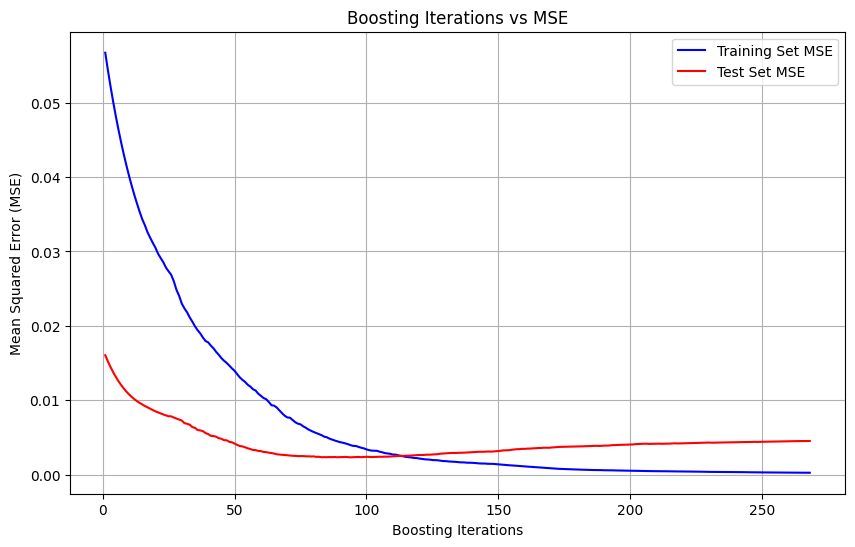

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model to compute test set scores for each boosting iteration
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(np.arange(best_params["n_estimators"]) + 1, best_model.train_score_, 'b-', label='Training Set MSE')
plt.plot(np.arange(best_params["n_estimators"]) + 1, test_score, 'r-', label='Test Set MSE')
plt.title('Boosting Iterations vs MSE')
plt.xlabel('Boosting Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [ ]:
structure = df.iloc[:,0]
structure

,Structures
0,K-01
1,K-02
2,K-03
3,K-04
4,K-05
5,K-06
6,K-07
7,K-08
8,K-09
9,K-10


In [ ]:
import pandas as pd

# Creating DataFrame for training set results
train_results = pd.DataFrame({'Structure': structure[train_indices],'Actual': y_train, 'Predicted': y_pred_train, 'Error': y_train - y_pred_train})
print("Train Set Results:")
print(train_results)

# Saving the training set results as a CSV file
train_results.to_csv('/content/drive/MyDrive/Senior_project/Results/GBR_train_reorder.csv', index=False)


# Creating DataFrame for test set results
test_results = pd.DataFrame({'Structure': structure[test_indices],'Actual': y_test, 'Predicted': y_pred_test, 'Error': y_test - y_pred_test})
print("Test Set Results:")
print(test_results)

# Saving the test set results as a CSV file
test_results.to_csv('/content/drive/MyDrive/Senior_project/Results/GBR_test_reorder.csv', index=False)

print("Results have been saved as 'train_results.csv' and 'test_results.csv'.")


Train Set Results:
   Structure    Actual  Predicted     Error
0       K-01  4.722391   4.732240 -0.009849
1       K-02  4.881405   4.872635  0.008769
3       K-04  4.522879   4.539456 -0.016578
5       K-06  4.835945   4.833388  0.002556
6       K-07  4.764472   4.759516  0.004956
7       K-08  4.898941   4.895305  0.003636
8       K-09  5.037631   5.010545  0.027086
9       K-10  4.522879   4.512961  0.009918
10      K-11  4.873219   4.891382 -0.018162
11      K-12  4.779892   4.803970 -0.024078
12      K-13  5.110698   5.091202  0.019497
13      K-14  4.522879   4.537147 -0.014268
14      K-15  5.402305   5.401181  0.001124
15      K-16  5.097453   5.089794  0.007659
16      K-17  5.124939   5.118839  0.006100
17      K-18  4.522879   4.529098 -0.006219
18      K-19  4.522879   4.545652 -0.022773
19      K-20  4.829152   4.824368  0.004784
20      K-21  5.137869   5.129136  0.008732
21      K-22  5.251812   5.236967  0.014845
23      K-24  4.881735   4.889603 -0.007868
25      K-26 

In [ ]:
_# Creating DataFrame for training set results
train_results = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred_train, 'Error': y_train - y_pred_train})
print("Train Set Results:")
print(train_results)

# Creating DataFrame for test set results
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test, 'Error': y_test - y_pred_test})
print("Test Set Results:")
print(test_results)


Train Set Results:
      Actual  Predicted     Error
0   4.722391   4.731383 -0.008992
1   4.881405   4.881504 -0.000100
22  4.764472   4.760235  0.004237
3   4.522879   4.541777 -0.018899
23  4.873219   4.891966 -0.018747
5   4.835945   4.825381  0.010563
6   4.898941   4.892483  0.006458
7   5.037631   5.012554  0.025077
8   4.522879   4.515555  0.007323
9   4.779892   4.804135 -0.024243
10  5.110698   5.090728  0.019971
11  4.522879   4.540332 -0.017453
12  5.402305   5.400516  0.001789
13  5.097453   5.087418  0.010035
14  5.124939   5.122134  0.002805
15  4.522879   4.529091 -0.006213
16  4.522879   4.537614 -0.014735
17  5.137869   5.131963  0.005906
18  5.251812   5.236221  0.015591
19  4.881735   4.887295 -0.005560
26  4.926282   4.949139 -0.022857
21  4.956638   4.928595  0.028043
Test Set Results:
      Actual  Predicted     Error
2   4.756218   4.809155 -0.052937
4   4.880414   4.785294  0.095120
24  4.829152   4.870321 -0.041170
25  4.927015   5.070846 -0.143831
20  4.93107

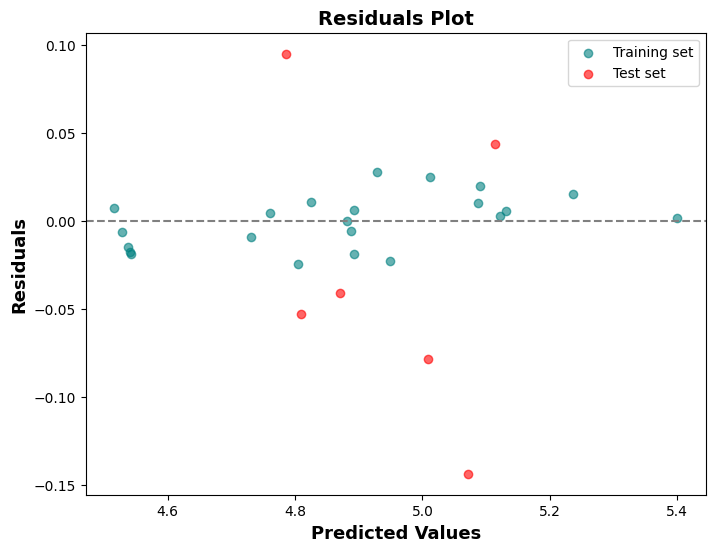

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Ensure that both the training and test residuals arrays are of the same length when combined
# Combine both train and test results into a single DataFrame for saving
residuals_combined_df = pd.DataFrame({
    'Predicted': pd.concat([pd.Series(y_pred_train), pd.Series(y_pred_test)], ignore_index=True),
    'Residuals': pd.concat([pd.Series(residuals_train), pd.Series(residuals_test)], ignore_index=True)
})

# Save the DataFrame to a CSV file
residuals_combined_df.to_csv('/content/drive/MyDrive/Senior_project/Results/GBR_RESIDUAL_2.csv', index=False)

# Plot residuals for training and test sets
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_train, residuals_train, color='teal', label='Training set', alpha=0.6)
plt.scatter(y_pred_test, residuals_test, color='red', label='Test set', alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Values', fontsize=13, fontweight='bold')
plt.ylabel('Residuals', fontsize=13, fontweight='bold')
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.legend()
#plt.show()


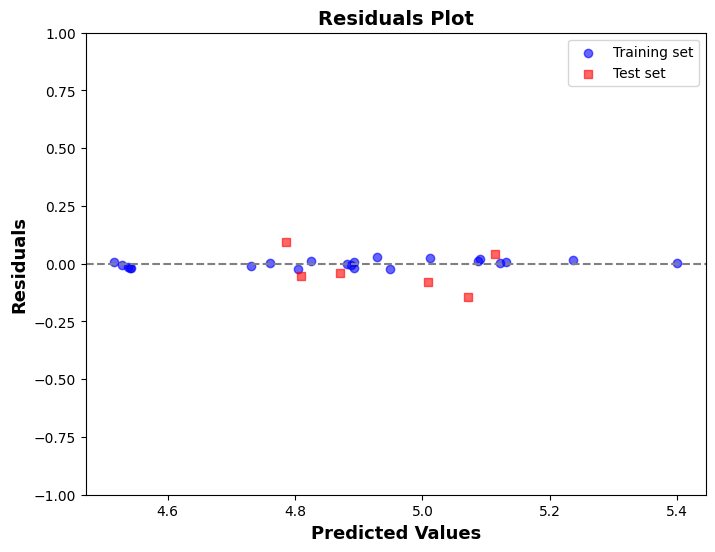

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# Ensure that both the training and test residuals arrays are of the same length when combined
# Combine both train and test results into a single DataFrame for saving
residuals_combined_df = pd.DataFrame({
    'Predicted': pd.concat([pd.Series(y_pred_train), pd.Series(y_pred_test)], ignore_index=True),
    'Residuals': pd.concat([pd.Series(residuals_train), pd.Series(residuals_test)], ignore_index=True)
})

# Save the DataFrame to a CSV file
residuals_combined_df.to_csv('/content/drive/MyDrive/Senior_project/Results/GBR_RESIDUAL.csv', index=False)

# Plot residuals for training and test sets
plt.figure(figsize=(8, 6))
plt.ylim(-1, 1)
plt.scatter(y_pred_train, residuals_train, color='blue', label='Training set', alpha=0.6)
plt.scatter(y_pred_test, residuals_test, color='red', label='Test set', alpha=0.6,marker='s')
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Predicted Values', fontsize=13, fontweight='bold')
plt.ylabel('Residuals', fontsize=13, fontweight='bold')
plt.title('Residuals Plot', fontsize=14, fontweight='bold')
plt.legend()
#plt.show()

Randomization

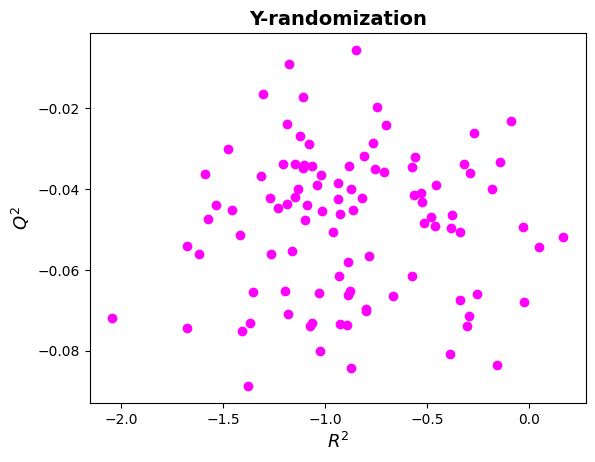

Y-randomization results have been saved as 'y_randomization_results.csv'.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.utils import shuffle

#FINAL BEST PARAMETERS
#Best Hyperparameters (Optuna): {'n_estimators': 268, 'max_depth': 6, 'min_samples_split': 13, 'learning_rate': 0.03126782587234565}

# Best hyperparameters obtained from Optuna optimization
best_params = {
    'n_estimators': 268,  # Replace with your optimized value
    'max_depth': 6,        # Replace with your optimized value
    'min_samples_split': 13,  # Replace with your optimized value
    'learning_rate': 0.03126782587234565   # Replace with your optimized value
}

# Y-randomization
n_iterations = 100
r2_scores = []
q2_scores = []

for i in range(n_iterations):
    # Shuffle the target variable (y_train)
    y_random = shuffle(y_train, random_state=i)

    # Train the model with the shuffled target variable
    model_random = GradientBoostingRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        learning_rate=best_params['learning_rate'],
        loss="squared_error"
    ).fit(X_train, y_random)

    # Predict on the training data
    y_pred_random = model_random.predict(X_train)

    # Calculate R^2 for the random model on training data
    r2_random = r2_score(y_train, y_pred_random)

    # Perform cross-validated predictions and calculate Q^2
    y_cv_pred = cross_val_predict(model_random, X_train, y_train, cv=5)
    q2_random = r2_score(y_train, y_cv_pred)

    # Append the scores
    r2_scores.append(r2_random)
    q2_scores.append(q2_random)

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'R^2_Score': r2_scores,
    'Q^2_Score': q2_scores
})

# Save the results to a CSV file in your directory
results_df.to_csv('/content/drive/MyDrive/Senior_project/Results/GBR_randomization.csv', index=False)

# Plotting Y-randomization
plt.scatter(r2_scores, q2_scores, color='magenta')
plt.xlabel('$R^2$', fontsize=13, fontweight='bold')
plt.ylabel('$Q^2$', fontsize=13, fontweight='bold')
plt.title('Y-randomization', fontsize=14, fontweight='bold')
plt.show()

print("Y-randomization results have been saved as 'y_randomization_results.csv'.")


PI

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import pandas as pd

In [ ]:
# Calculate permutation importance on the test set
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Get feature names from X_test columns
feature_names = X_test.columns

# Create a DataFrame for better readability
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
})

# Sort features by mean importance in descending order
importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)

# Select the top 10 features
top_10_features = importance_df.head(10)

print("Top 10 Features by Permutation Importance:")
print(top_10_features)

Top 10 Features by Permutation Importance:
  Feature  Importance_Mean  Importance_Std
0    X127         1.375029        0.856439
2     X16         0.956227        0.385134
1    X144         0.806664        0.491129


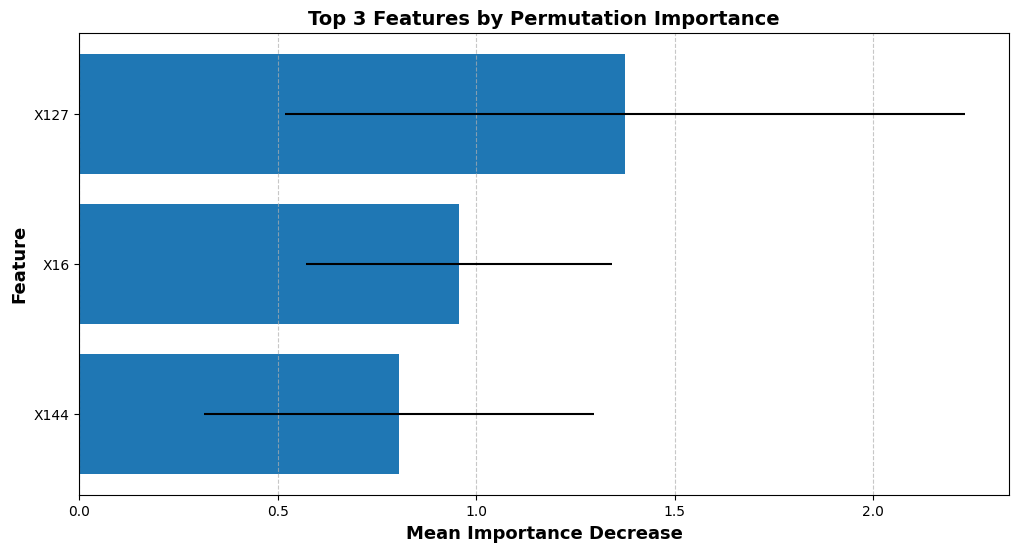

In [ ]:
# Plot the top 10 features
plt.figure(figsize=(12, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance_Mean'], xerr=top_10_features['Importance_Std'], align='center')
plt.xlabel('Mean Importance Decrease', fontsize=13, fontweight='bold')
plt.ylabel('Feature', fontsize=13, fontweight='bold')
plt.title('Top 3 Features by Permutation Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

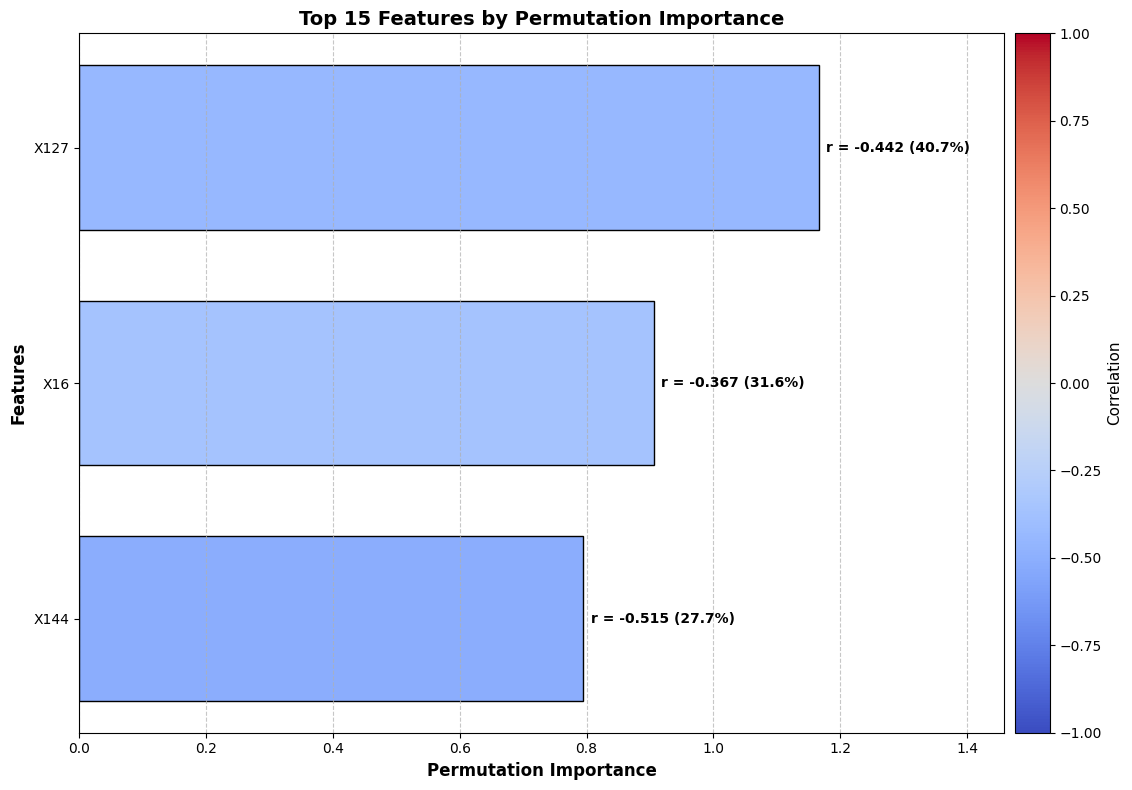

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.inspection import permutation_importance
from scipy.stats import pearsonr

# Compute permutation importance
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)

# Create DataFrame
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
})

# Compute Pearson correlation with target
perm_df['Correlation'] = [pearsonr(X_test[col], y_test)[0] for col in X_test.columns]

# Sort and keep top 15
perm_df = perm_df.sort_values('Importance', ascending=False).head(15)

# Calculate percentage of total importance
total_importance = perm_df['Importance'].sum()
perm_df['Percentage'] = (perm_df['Importance'] / total_importance) * 100

# Sort for plotting (most important at top)
perm_df = perm_df.sort_values('Importance', ascending=True)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 8))

# Create colormap for correlation values
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = plt.get_cmap('coolwarm')
colors = cmap(norm(perm_df['Correlation']))

# Horizontal bar plot without error bars
bars = ax.barh(
    perm_df['Feature'],
    perm_df['Importance'],
    color=colors,
    edgecolor='black',
    height=0.7
)

# Add correlation and percentage labels
max_importance = perm_df['Importance'].max()
for i, (imp, corr, pct) in enumerate(zip(perm_df['Importance'],
                                        perm_df['Correlation'],
                                        perm_df['Percentage'])):
    x_pos = imp + (0.01 * max_importance)
    ax.text(
        x_pos, i,
        f"r = {corr:.3f} ({pct:.1f}%)",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Style adjustments
ax.set_xlim(0, max_importance * 1.25)  # Start from 0 and extend slightly beyond max value
ax.set_xlabel("Permutation Importance", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
ax.set_title("Top 15 Features by Permutation Importance", fontsize=14, fontweight='bold')

# Add grid for better readability
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Correlation", fontsize=11)

plt.tight_layout()
plt.show()

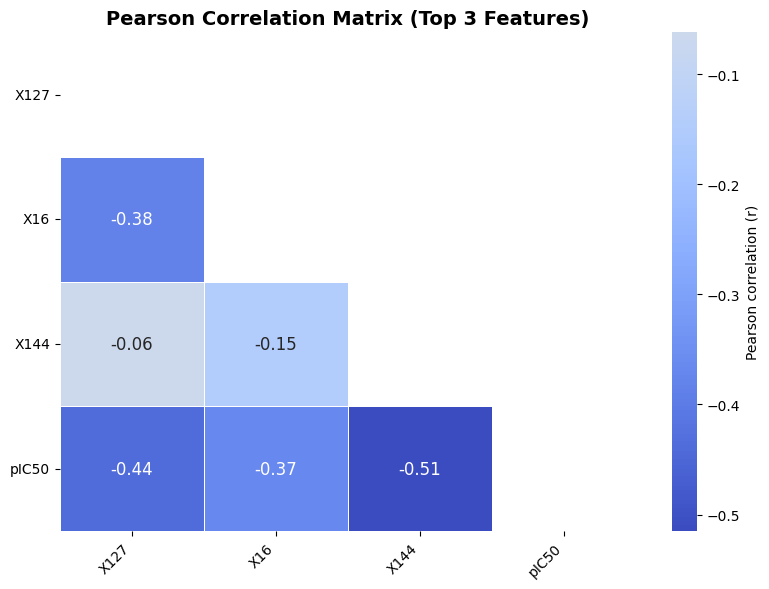

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Select top 3 features from permutation importance
top_features = perm_df.sort_values('Importance', ascending=False)['Feature'].head(3).tolist()
# Merge selected features with target
df_corr = pd.concat(
    [
        X_test[top_features].reset_index(drop=True),
        y_test.reset_index(drop=True).rename('pIC50')
    ],
    axis=1
)

# Force numeric for safety
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')

ordered_cols = top_features + ['pIC50']
corr_matrix = df_corr[ordered_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 12},
    cbar_kws={"label": "Pearson correlation (r)"}
)

plt.title("Pearson Correlation Matrix (Top 3 Features)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Assuming best_params and best_model are already defined
test_score = np.zeros((best_params["n_estimators"],), dtype=np.float64)

# Using the best_model instead of GBR
for i, y_pred in enumerate(best_model.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

# Prepare data for saving
data = {
    "Boosting Iterations": np.arange(1, best_params["n_estimators"] + 1),
    "Training Set Score": best_model.train_score_,
    "Test Set Score": test_score
}

# Create a DataFrame
output_df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
output_df.to_csv('/content/drive/MyDrive/Senior_project/Results/GBRLOSS_OUT.csv', index=False)

print("Output saved to /content/drive/MyDrive/Senior_project/Results/GBRLOSS_OUT.csv")


Output saved to /content/drive/MyDrive/Senior_project/Results/GBRLOSS_OUT.csv


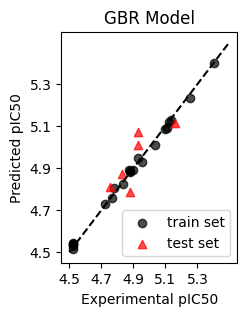

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data visualization
plt.figure(figsize=(5, 3))

# 1 row, 2 column, plot 1
plt.subplot(1, 2, 1)

plt.scatter(x=y_train, y=y_pred_train, c="black", alpha=0.7)
plt.scatter(x=y_test, y=y_pred_test, c="r", marker='^', alpha=0.7)

plt.legend(("train set", "test set"), loc="lower right")
plt.plot([4.5, 5.5], [4.5, 5.5], "--", color="black")

x_ticks = np.arange(4.5, 5.5, 0.2)
y_ticks = np.arange(4.5, 5.5, 0.2)

plt.xticks(x_ticks)
plt.yticks(y_ticks)

plt.title('GBR Model')
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')

plt.show()


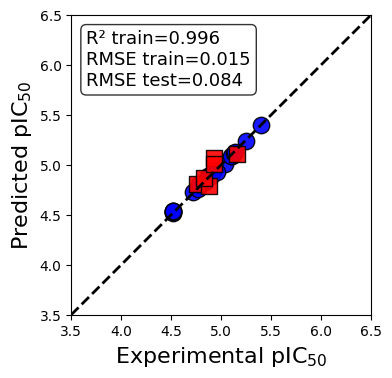

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def calc_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    r2 = r2_score(y_true_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    return r2, rmse_train, rmse_test

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# Calculate metrics
metrics = calc_metrics(y_train, y_pred_train, y_test, y_pred_test)

# Create figure (single axis)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Scatter plots
ax.scatter(
    y_train, y_pred_train,
    color='blue', marker='o', edgecolor='k',
    s=140, alpha=0.9, label='Train'
)

ax.scatter(
    y_test, y_pred_test,
    color='red', marker='s', edgecolor='k',
    s=140, alpha=0.9, label='Test'
)

# Reference line
min_val, max_val = 3.5, 6.5
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal', adjustable='box')

ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

#ax.set_title('GBR', fontsize=14)
ax.set_xlabel('Experimental pIC$_{50}$', fontsize=16)
ax.set_ylabel('Predicted pIC$_{50}$', fontsize=16)

inset_text = f"R² train={metrics[0]:.3f}\nRMSE train={metrics[1]:.3f}\nRMSE test={metrics[2]:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(0.05, 0.95, inset_text, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', bbox=props)



# Legend
#ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Senior_project/Results/plot_expvspred_GBR.tif',
    dpi=300, format='tif'
)
plt.show()

In [ ]:
!pip install shap

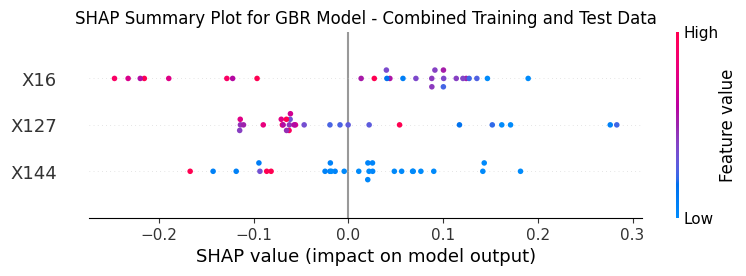

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Summary plot of combined SHAP values with feature names
shap.summary_plot(shap_values_combined, X_combined_df, show=False)
plt.title("SHAP Summary Plot for GBR Model - Combined Training and Test Data")
plt.show()

In [ ]:
import shap
import pandas as pd
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-4:]
top_3_features = X_combined_df.columns[top_3_indices]

# Print SHAP values and corresponding feature values for top 3 features
for i, feature in enumerate(top_3_features):
    print(f"\nFeature: {feature}")
    print("SHAP Value, Feature Value")
    for shap_val, feature_val in zip(shap_values_combined[:, top_3_indices[i]], X_combined_df[feature]):
        print(f"{shap_val}, {feature_val}")



Feature: X144
SHAP Value, Feature Value
-0.1672436155706898, 4.00367618
-0.08639970850642632, 3.98031305
0.020492494819667296, 0.21222599
-0.00454321875176075, 0.04236468
-0.14298580470064984, 0.29142409
-0.09461780018682475, 0.38396059
-0.019643889653128677, 0.2794257
0.06837811939377306, 0.05558409
-0.08175964339402113, 4.03392601
-0.024751739358180203, 0.21915475
0.14336596699749035, 0.03786285
0.010836699211557227, 0.01275838
0.18167806913730933, 0.00830135
0.05615474097926794, 0.06989386
0.025518005712828282, 0.14363941
-0.01810568985357267, 0.00909914
0.021696807198168244, 0.03868514
0.07645987818316578, 0.01266828
0.04841854201665476, 0.04193183
-0.019159534296208716, 0.26521656
0.020339724018082383, 0.10471026
-0.014128403396501777, 0.23841093
-0.0935485259221671, 1.36799185
-0.1185992888465328, 0.30394975
0.09007462410127945, 0.03509991
0.14188345434575406, 0.03050397
0.06769560195243685, 0.06993135
0.02533476247845101, 0.18300982

Feature: X127
SHAP Value, Feature Value
-0.0

In [ ]:
import shap
import pandas as pd
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-3:]
top_3_features = X_combined_df.columns[top_3_indices]

# Create a DataFrame to store SHAP values and feature values for top 3 features
output_df = pd.DataFrame()

for i, feature in enumerate(top_3_features):
    output_df[f"{feature}_SHAP"] = shap_values_combined[:, top_3_indices[i]]
    output_df[f"{feature}_Value"] = X_combined_df[feature].values

# Specify the path to save the CSV file
output_path = '/content/drive/MyDrive/Senior_project/Results/GBR_shap_values_top3_features.csv'

# Save the DataFrame to the specified CSV file
output_df.to_csv(output_path, index=False)

print(f"CSV file saved as '{output_path}'")


CSV file saved as '/content/drive/MyDrive/Senior_project/Results/GBR_shap_values_top3_features.csv'


<Figure size 1600x1600 with 0 Axes>

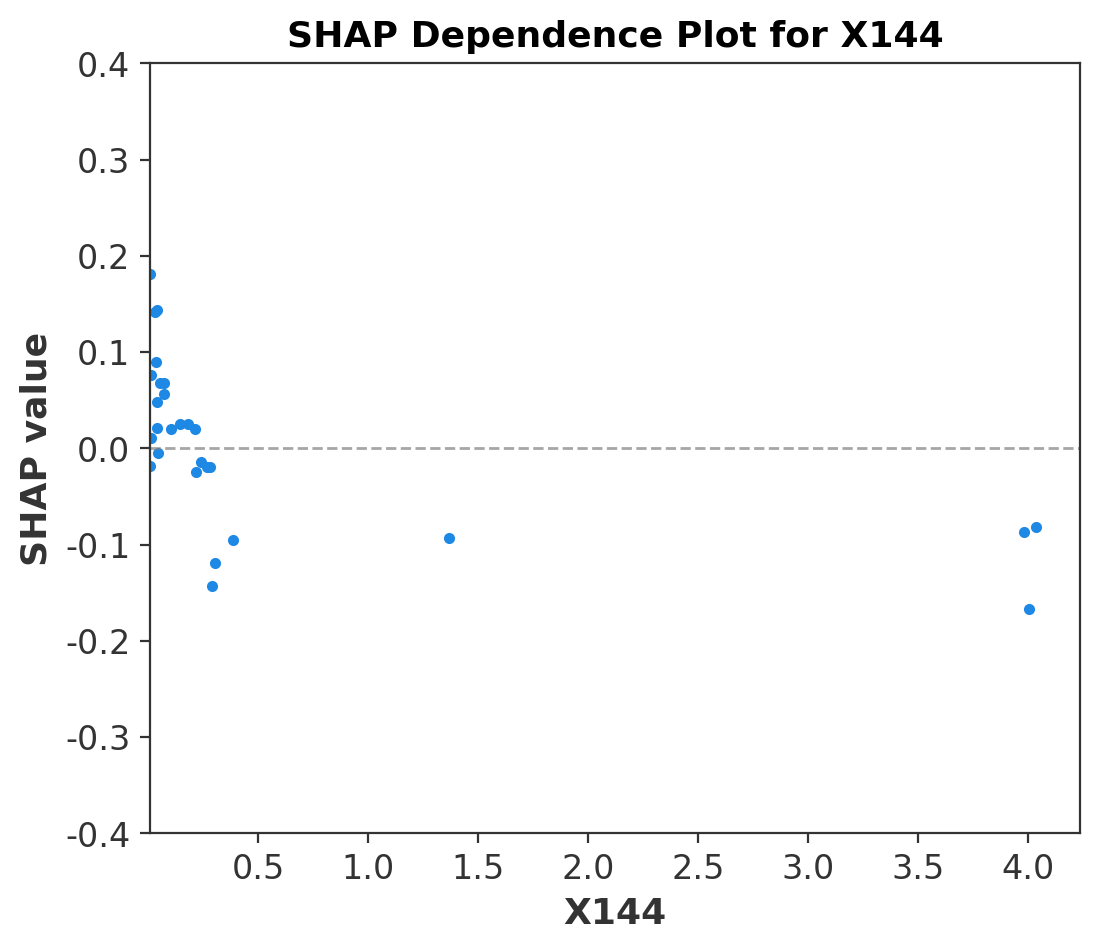

<Figure size 1600x1600 with 0 Axes>

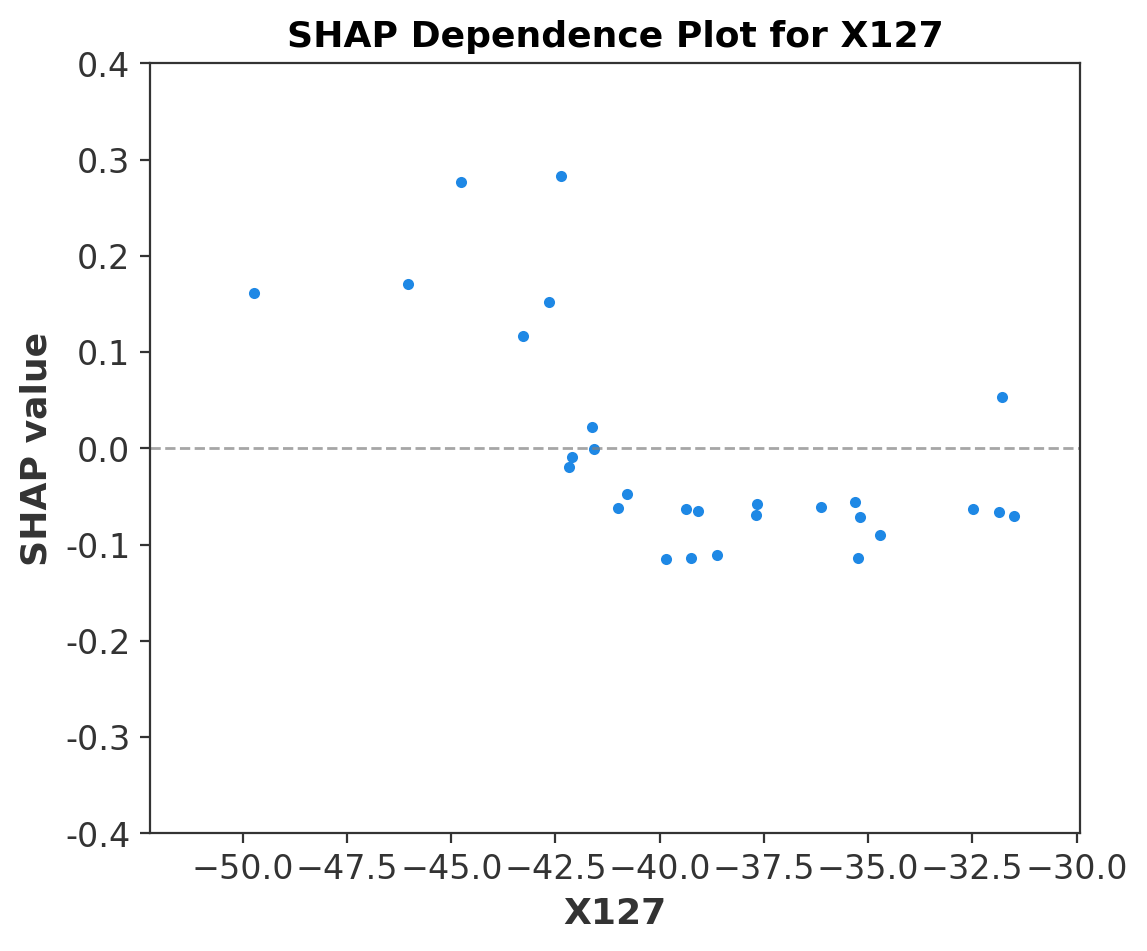

<Figure size 1600x1600 with 0 Axes>

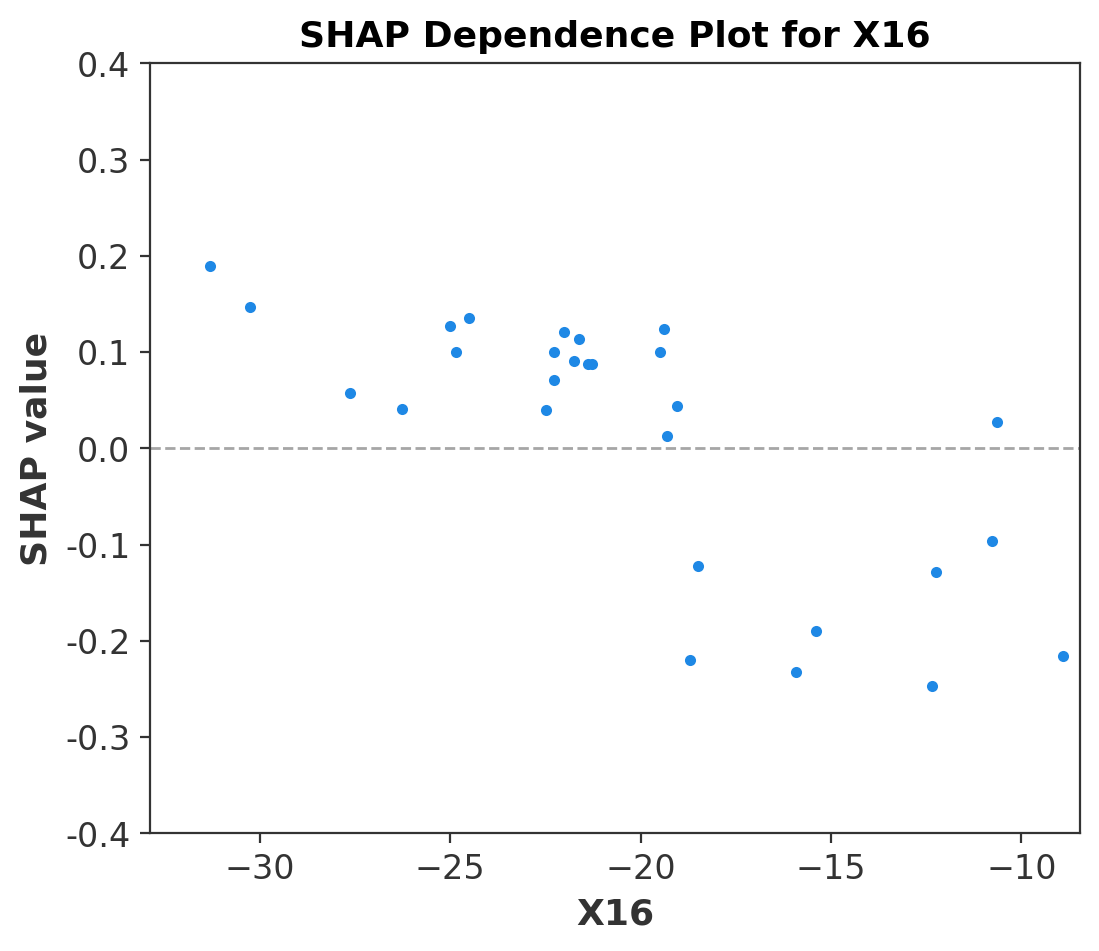

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-3:]
top_3_features = X_combined_df.columns[top_3_indices]

# Filter SHAP values and data for top 3 features
shap_values_combined_top3 = shap_values_combined[:, top_3_indices]
X_combined_df_top3 = X_combined_df.iloc[:, top_3_indices]

# Set up Matplotlib font properties
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 200

# Generate SHAP dependence plots for each of the top 3 features with square plots
for feature in top_3_features:
    plt.figure(figsize=(8, 8))  # Set square figure size (8x8 inches)

    # Create the SHAP dependence plot
    shap.dependence_plot(
        feature,
        shap_values_combined,
        X_combined_df,
        interaction_index=None,
        show=False
    )

    # Get current axes object
    ax = plt.gca()

    # Customize the spines to add axes on top and right
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # Set the aspect ratio to be square
    ax.set_aspect('auto')

    # Set y-ticks to range from -0.5 to 1.5
    plt.yticks(np.arange(-1.0, 1.6, 0.5), fontsize=12, fontweight='normal')

    # Set x-ticks and remove bold font weight
    plt.xticks(fontsize=12, fontweight='normal')

    plt.title(f"SHAP Dependence Plot for {feature}", fontsize=13, fontweight='bold')
    plt.xlabel(feature, fontsize=13, fontweight='bold')
    plt.ylabel("SHAP value", fontsize=13, fontweight='bold')

    # Adjust x and y limits to ensure proper spacing
    plt.xlim(X_combined_df[feature].min() - 0.05 * np.abs(X_combined_df[feature].min()),
             X_combined_df[feature].max() + 0.05 * np.abs(X_combined_df[feature].max()))
    from matplotlib.ticker import MultipleLocator, FormatStrFormatter

    # Y-axis detailed scale
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    plt.ylim(-0.4, 0.4)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    plt.show()


<Figure size 1600x1600 with 0 Axes>

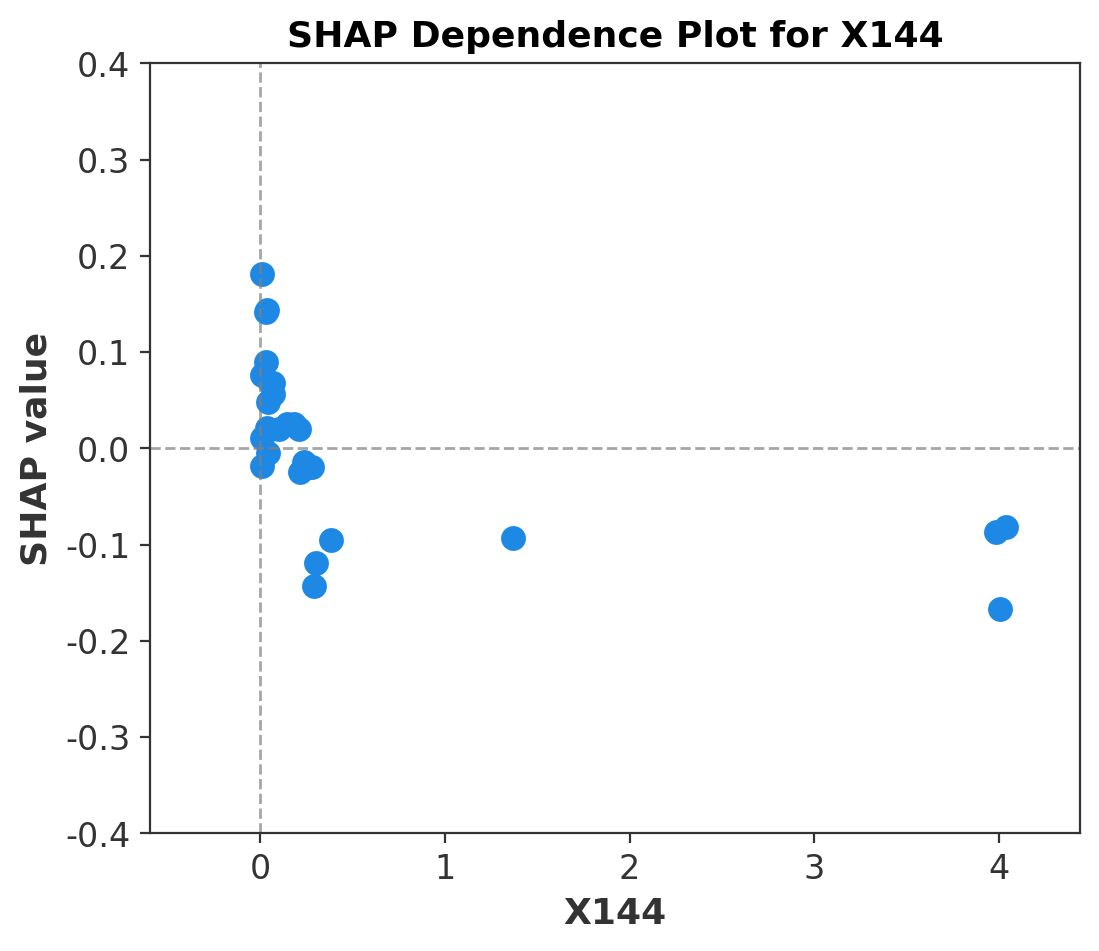

<Figure size 1600x1600 with 0 Axes>

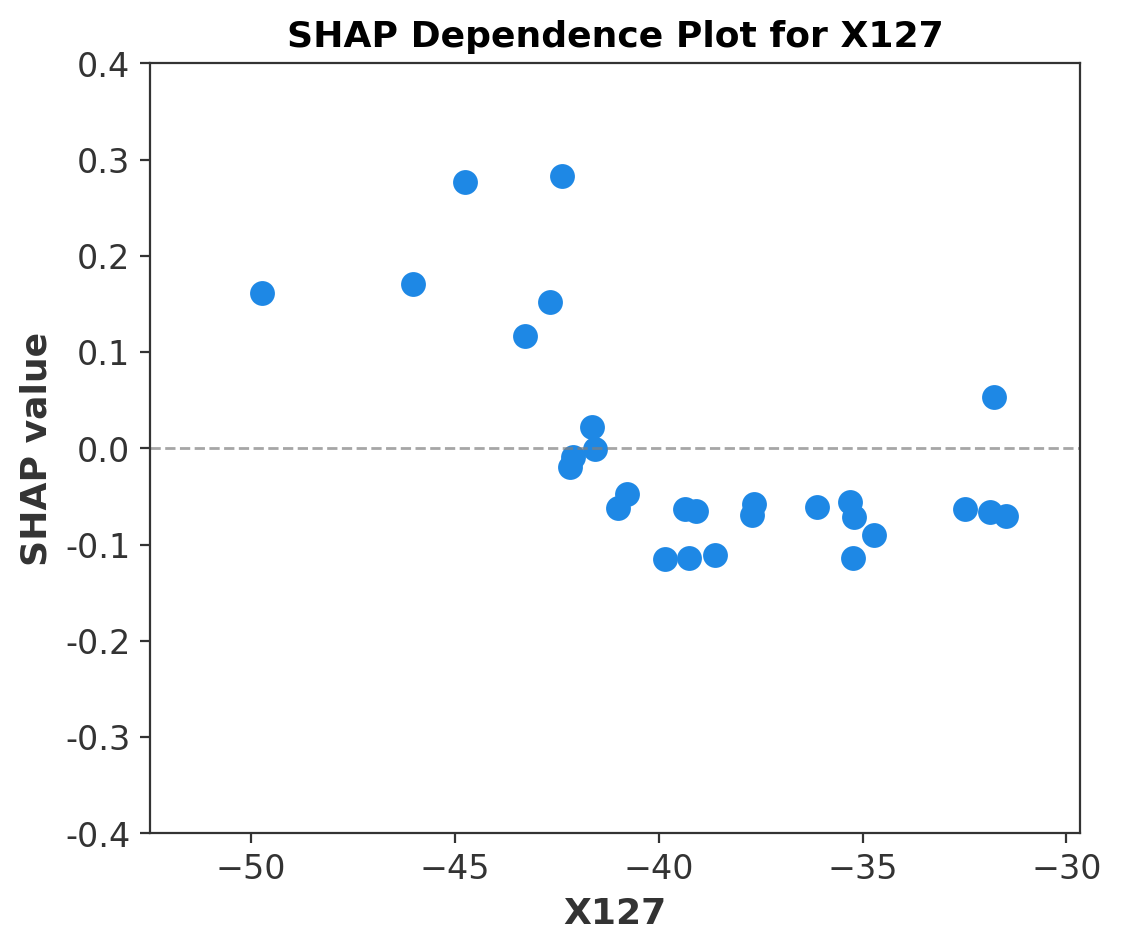

<Figure size 1600x1600 with 0 Axes>

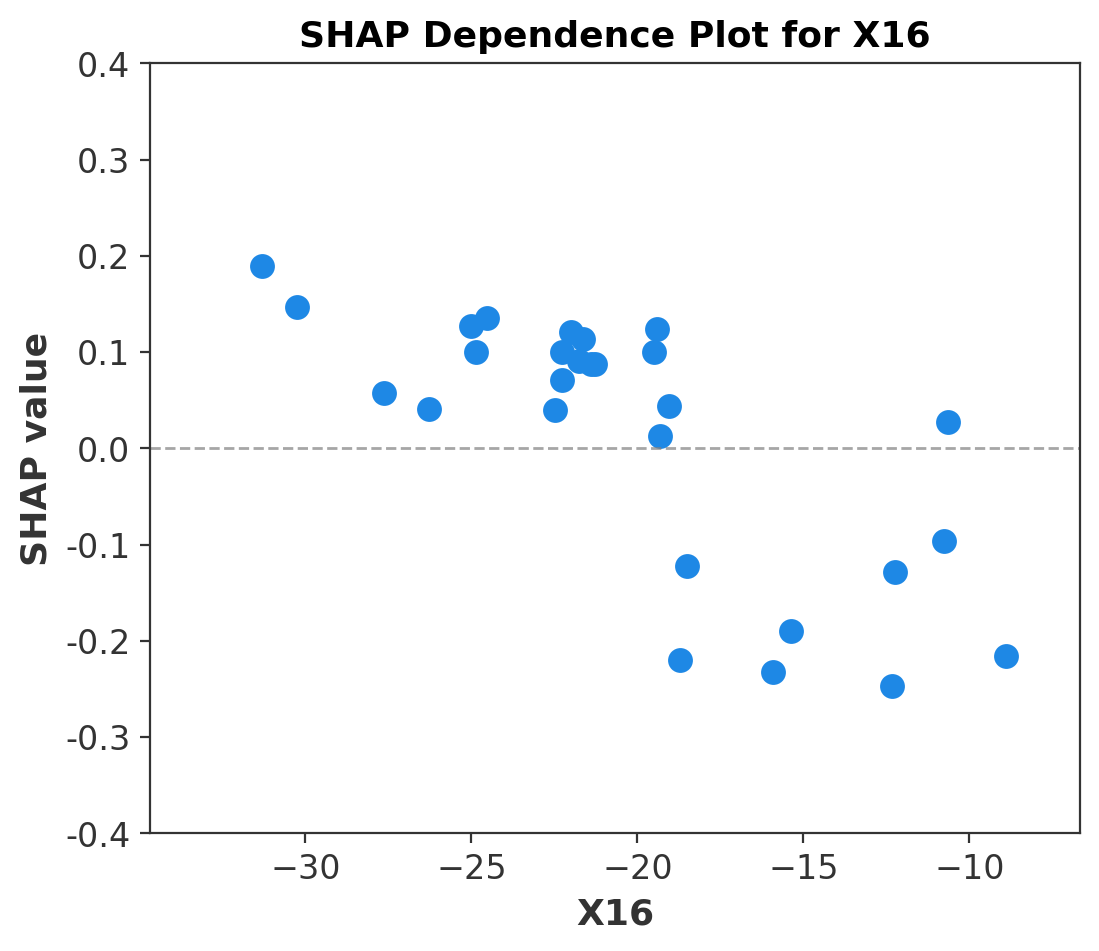

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assume model, X_train, and X_test are already defined

# SHAP Analysis
explainer = shap.Explainer(best_model, X_train)
shap_values_train = explainer(X_train)
shap_values_test = explainer(X_test)

# Create Pandas DataFrames with feature names for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Concatenate SHAP values and data
shap_values_combined = np.concatenate((shap_values_train.values, shap_values_test.values), axis=0)
X_combined_df = pd.concat([X_train_df, X_test_df], axis=0)

# Calculate mean absolute SHAP values to identify top 3 features
mean_abs_shap_values = np.mean(np.abs(shap_values_combined), axis=0)
top_3_indices = np.argsort(mean_abs_shap_values)[-3:]
top_3_features = X_combined_df.columns[top_3_indices]

# Filter SHAP values and data for top 3 features
shap_values_combined_top3 = shap_values_combined[:, top_3_indices]
X_combined_df_top3 = X_combined_df.iloc[:, top_3_indices]

# Set up Matplotlib font properties
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 200

# Generate SHAP dependence plots for each of the top 3 features with square plots
for feature in top_3_features:
    plt.figure(figsize=(8, 8))  # Set square figure size (8x8 inches)

    # Create the SHAP dependence plot
    shap.dependence_plot(
        feature,
        shap_values_combined,
        X_combined_df,
        interaction_index=None,
        dot_size=80,
        show=False
    )

    # Get current axes object
    ax = plt.gca()

    # Customize the spines to add axes on top and right
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # Set the aspect ratio to be square
    ax.set_aspect('auto')

    # Set y-ticks to range from -0.5 to 1.5
    plt.yticks(np.arange(-1.0, 1.6, 0.5), fontsize=12, fontweight='normal')

    # Set x-ticks and remove bold font weight
    plt.xticks(fontsize=12, fontweight='normal')

    plt.title(f"SHAP Dependence Plot for {feature}", fontsize=13, fontweight='bold')
    plt.xlabel(feature, fontsize=13, fontweight='bold')
    plt.ylabel("SHAP value", fontsize=13, fontweight='bold')

    # Adjust x and y limits to ensure proper spacing
    x_min = X_combined_df[feature].min()
    x_max = X_combined_df[feature].max()
    x_range = x_max - x_min

    plt.xlim(
            x_min - 0.15 * x_range,
            x_max + 0.10 * x_range
            )
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    plt.ylim(-0.4, 0.4)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    plt.show()

In [ ]:
# --- 7.1 Calculate SHAP Values ---
print("Calculating SHAP values...") # Print message indicating SHAP values are being calculated
explainer = shap.TreeExplainer(best_model) # Create a SHAP explainer for tree models. `best_model` is our trained model (e.g., XGBoost, LightGBM, etc.)
shap_values = explainer.shap_values(X_test) # Calculate SHAP values for each sample in the test set `X_test`

print(f"SHAP values shape: {shap_values.shape}") # Print the shape of the SHAP values array

# Corrected way to handle expected_value for multi-output models
if isinstance(explainer.expected_value, np.ndarray):
    print(f"Base value (expected_value): {explainer.expected_value}") # Print the array directly
    print(f"Base value shape: {explainer.expected_value.shape}")

    # If you want formatted output for each target
    for i, expected_val in enumerate(explainer.expected_value):
        print(f"Base value for target variable {i}: {expected_val:.4f}")
else:
    print(f"Base value (expected_value): {explainer.expected_value:.4f}") # Single-output model

Calculating SHAP values...
SHAP values shape: (6, 3)
Base value (expected_value): [4.87718265]
Base value shape: (1,)
Base value for target variable 0: 4.8772


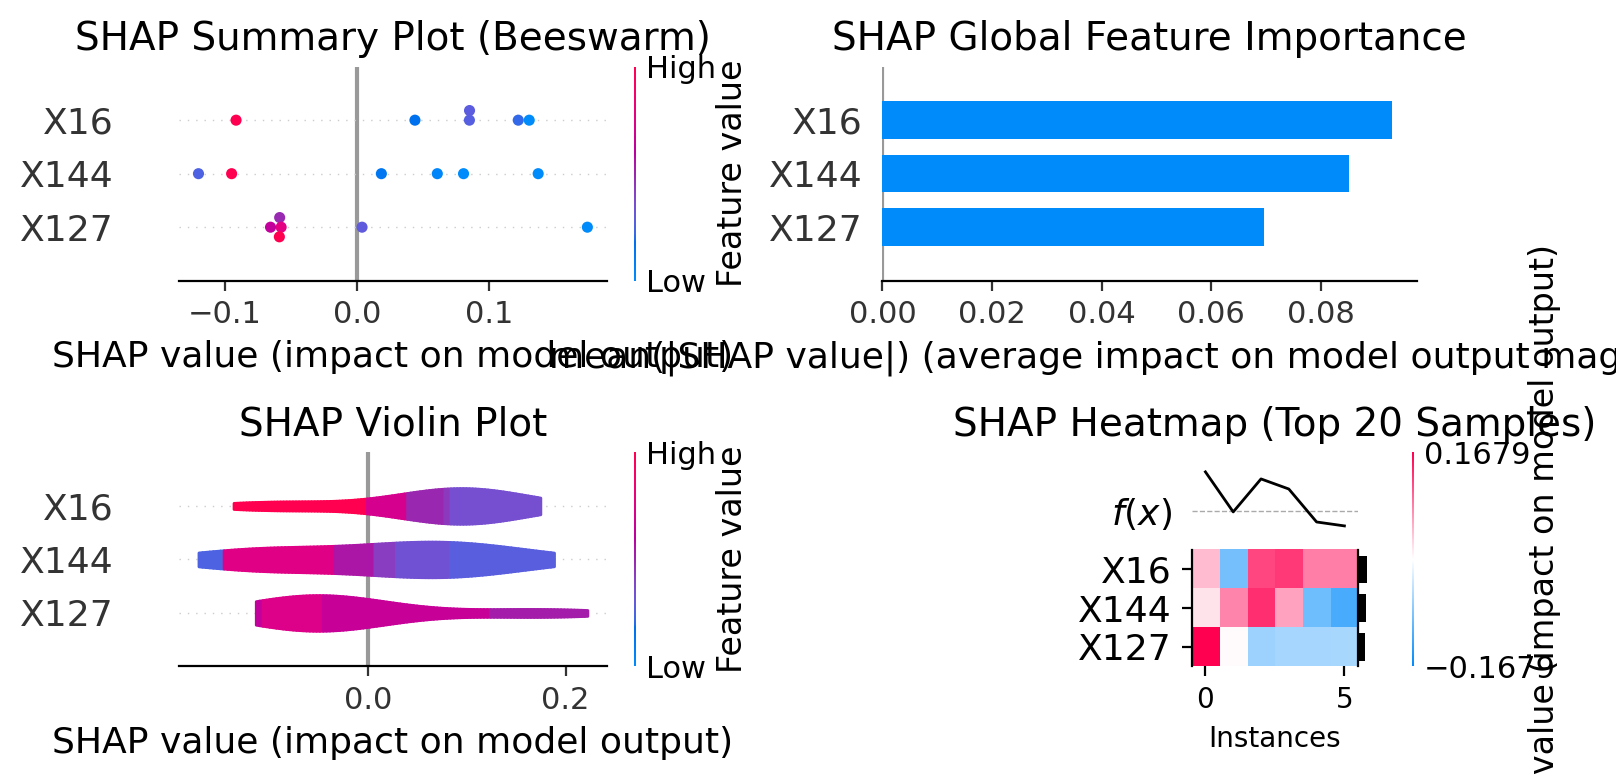

In [ ]:
# --- 7.2 SHAP Summary Plot Series ---
fig, axes = plt.subplots(2, 2, figsize=(20, 16)) # Create a 2x2 subplot grid to contain four different SHAP summary plots

# Beeswarm plot
plt.subplot(2, 2, 1) # Select first subplot position (top-left)
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False) # Create beeswarm plot, the most common summary plot type
plt.title("SHAP Summary Plot (Beeswarm)", fontsize=14) # Set subplot title

# Bar plot
plt.subplot(2, 2, 2) # Select second subplot position (top-right)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False) # Create bar plot showing global feature importance
plt.title("SHAP Global Feature Importance", fontsize=14) # Set subplot title

# Violin plot
plt.subplot(2, 2, 3) # Select third subplot position (bottom-left)
shap.summary_plot(shap_values, X_test, plot_type="violin", show=False) # Create violin plot showing SHAP value distributions
plt.title("SHAP Violin Plot", fontsize=14) # Set subplot title

# Heatmap for top samples
plt.subplot(2, 2, 4) # Select fourth subplot position (bottom-right)
shap.plots.heatmap(shap.Explanation(values=shap_values[:20], # Use SHAP values for first 20 samples
                                    base_values=explainer.expected_value, # Pass base values
                                    data=X_test.values[:20], # Pass original feature values for first 20 samples
                                    feature_names=X_test.columns.tolist()), # Pass feature names list
                   show=False) # Create heatmap, show=False means don't display immediately
plt.title("SHAP Heatmap (Top 20 Samples)", fontsize=14) # Set subplot title

plt.tight_layout() # Automatically adjust subplot parameters to fill the entire figure area
plt.savefig('SHAP_Comprehensive_Analysis.png', dpi=300, bbox_inches='tight') # Save the entire figure as a file
plt.show() # Display the completed plot

Generating SHAP waterfall plots...


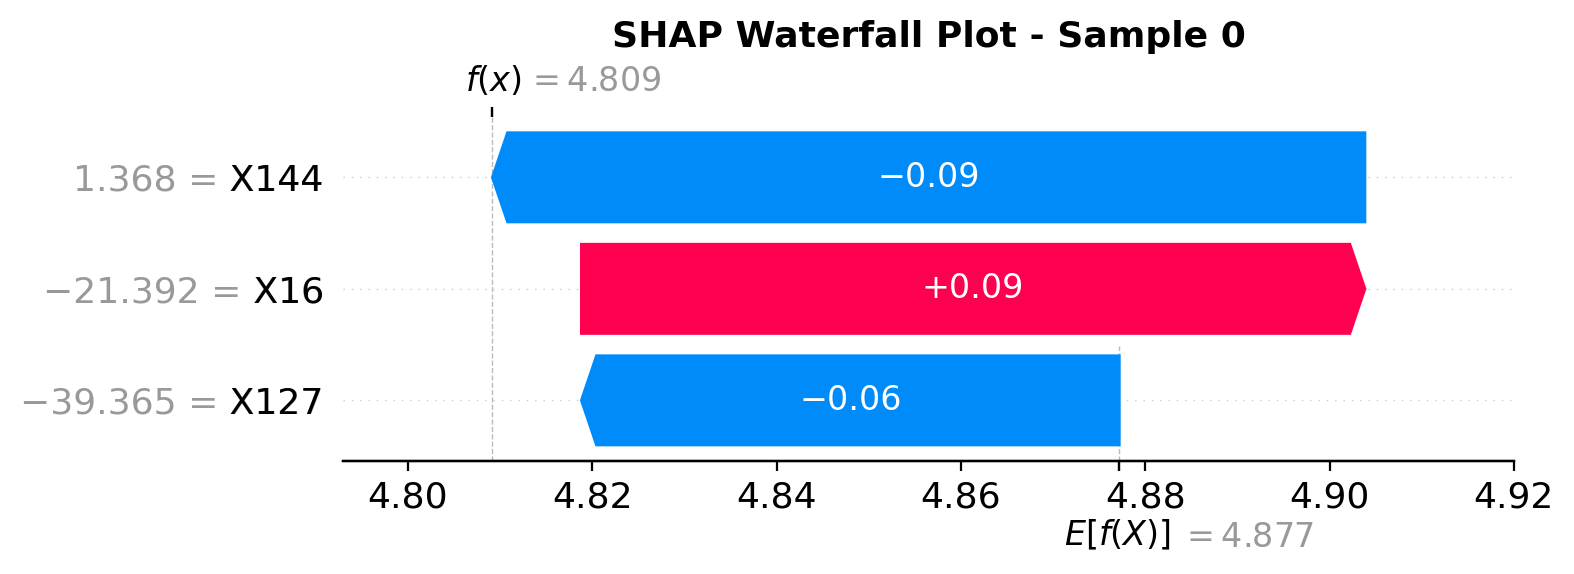

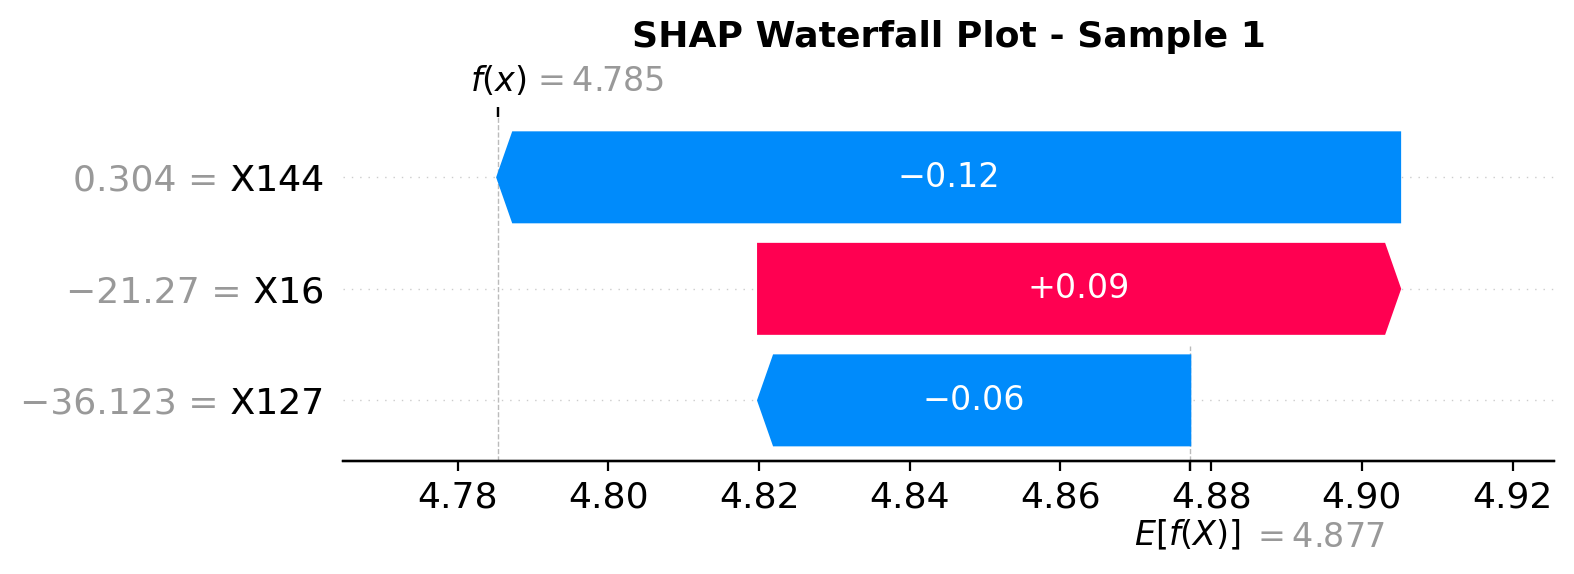

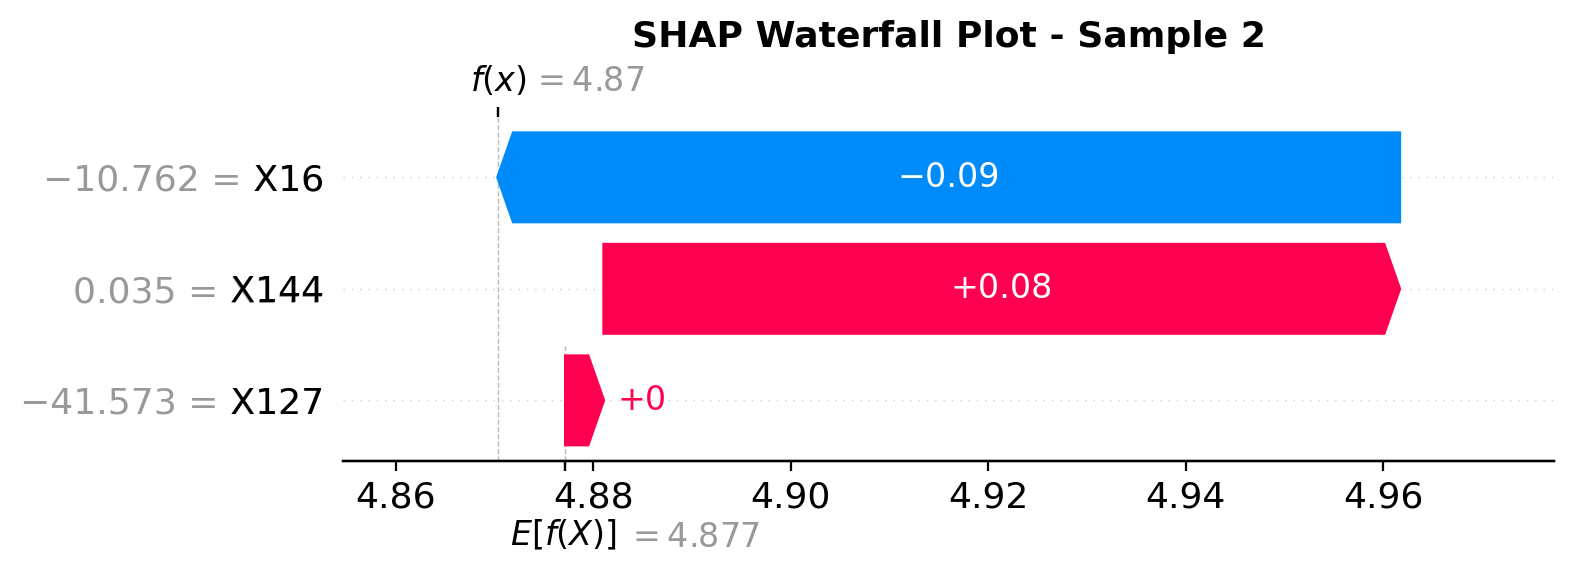

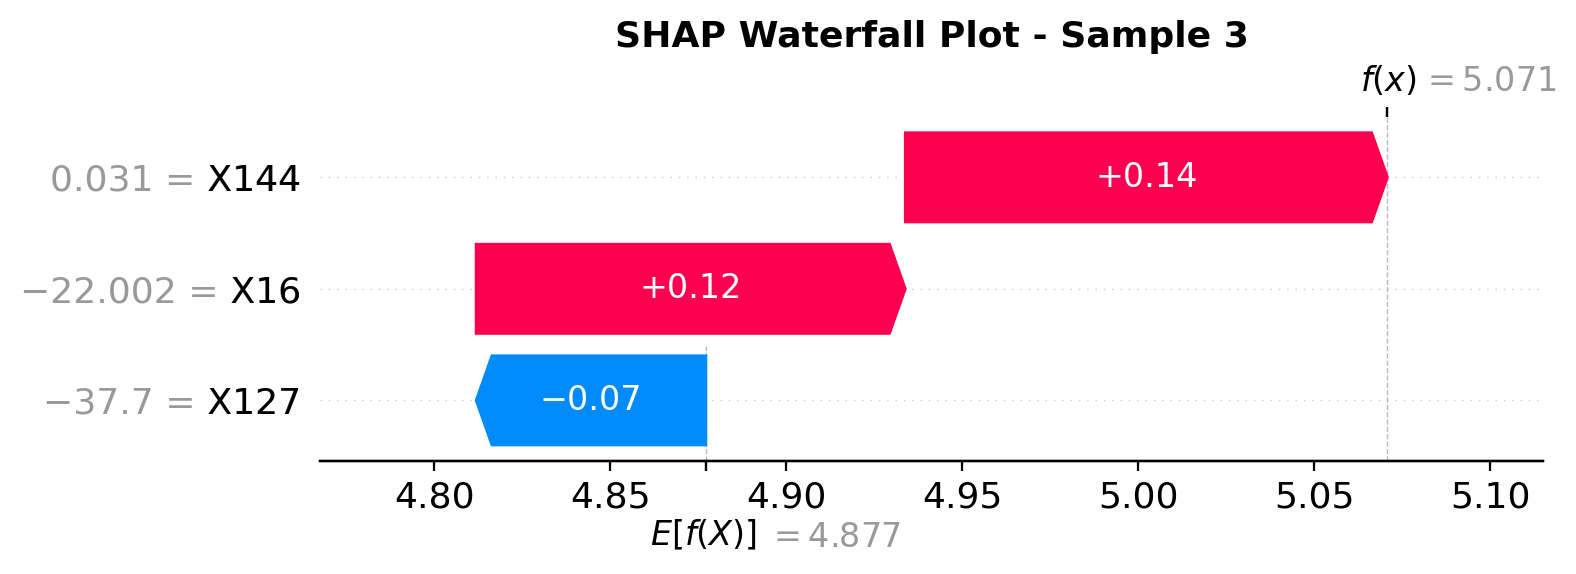

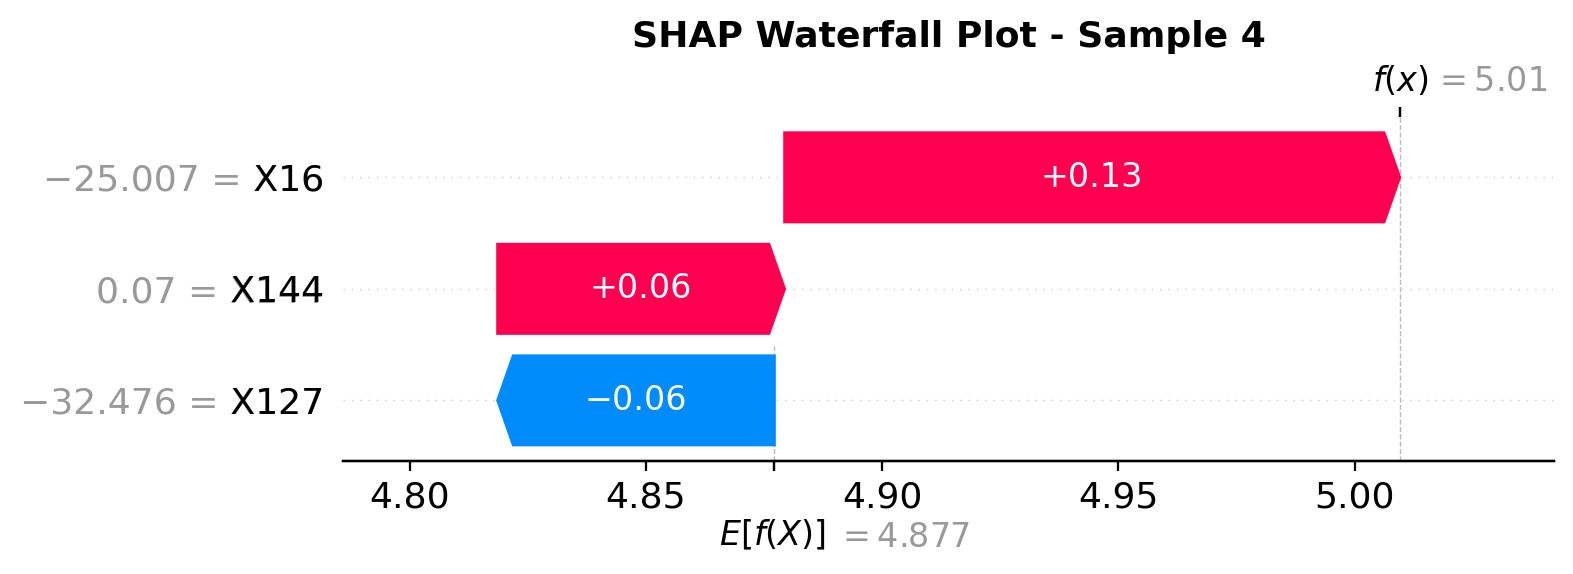

IndexError: index 19 is out of bounds for axis 0 with size 6

In [ ]:
import shap
import matplotlib.pyplot as plt

# --- 7.4 SHAP Waterfall Plots (Individual Prediction Breakdown) ---
print("Generating SHAP waterfall plots...")  # Status message

# Specify samples you want to analyze
sample_indices = [0,1,2,3,4,19]  # Customize as needed

# Adjust font size for readability
plt.rcParams.update({'font.size': 11})

for idx in sample_indices:
    # Create SHAP explanation for the sample
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )

    # Plot waterfall for the sample
    shap.plots.waterfall(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot - Sample {idx}', fontsize=13, weight='bold')
    plt.tight_layout()

    # Save each plot separately (optional)
    plt.savefig(f'SHAP_Waterfall_Sample_{idx}.png', dpi=500, bbox_inches='tight')

    # Show the plot
    plt.show()


Generating SHAP partial dependence plots...


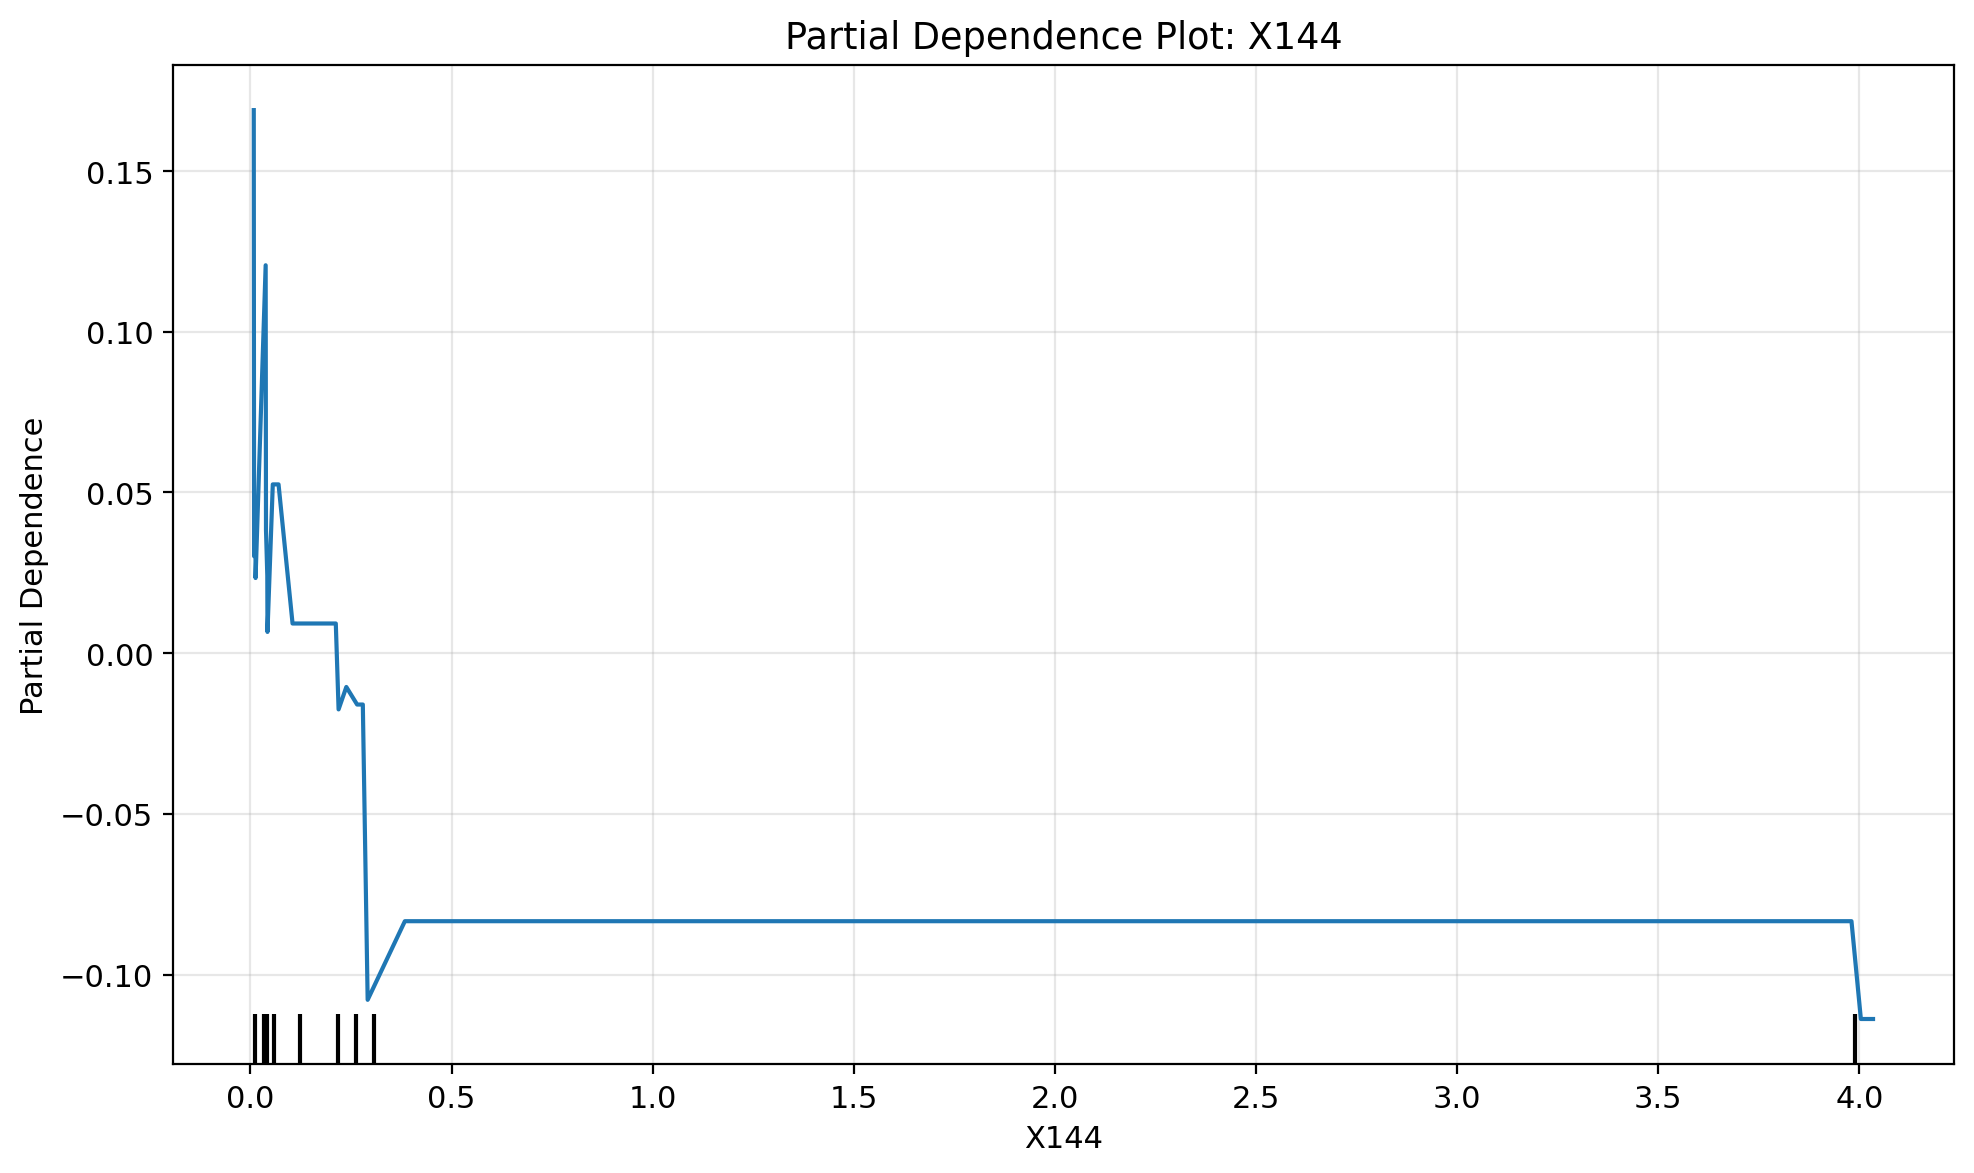

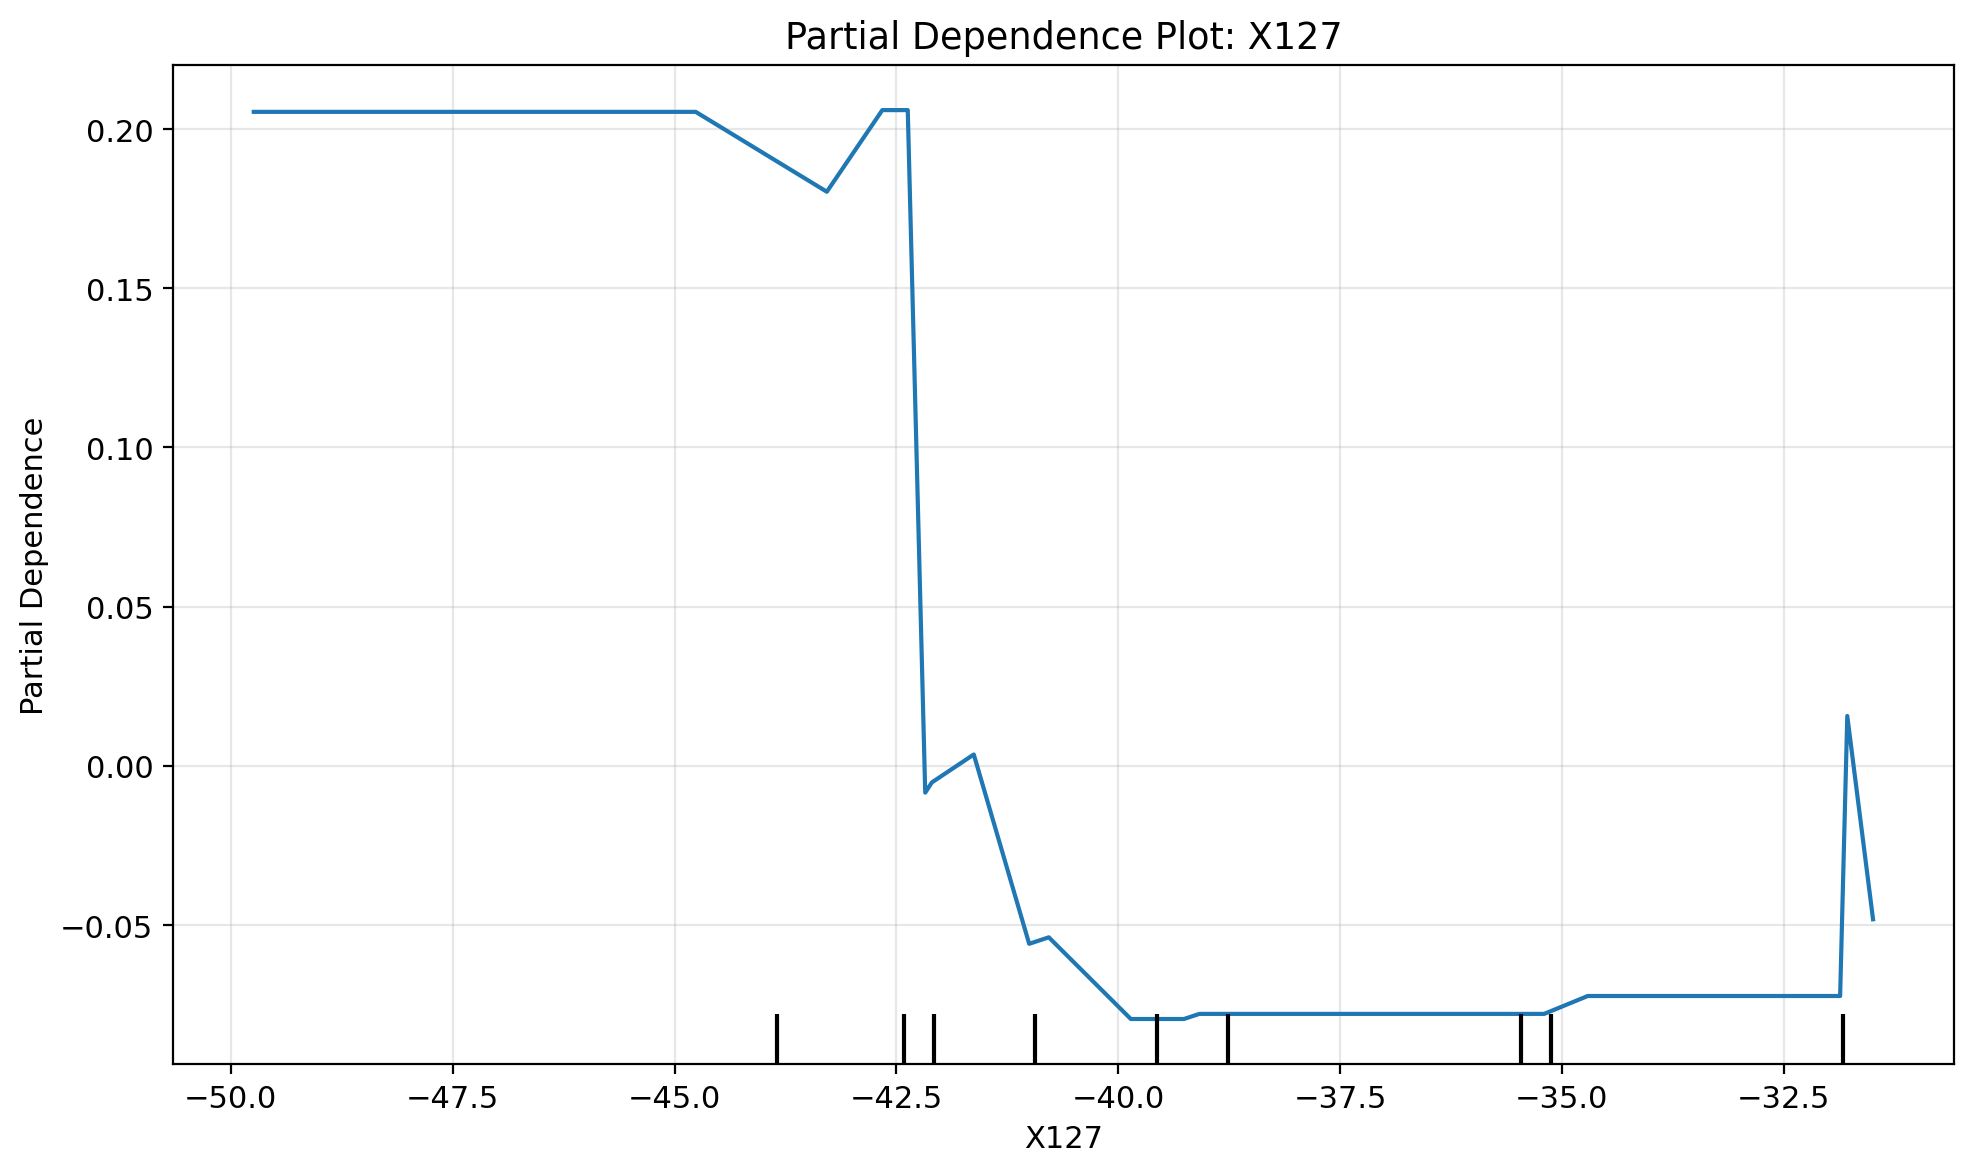

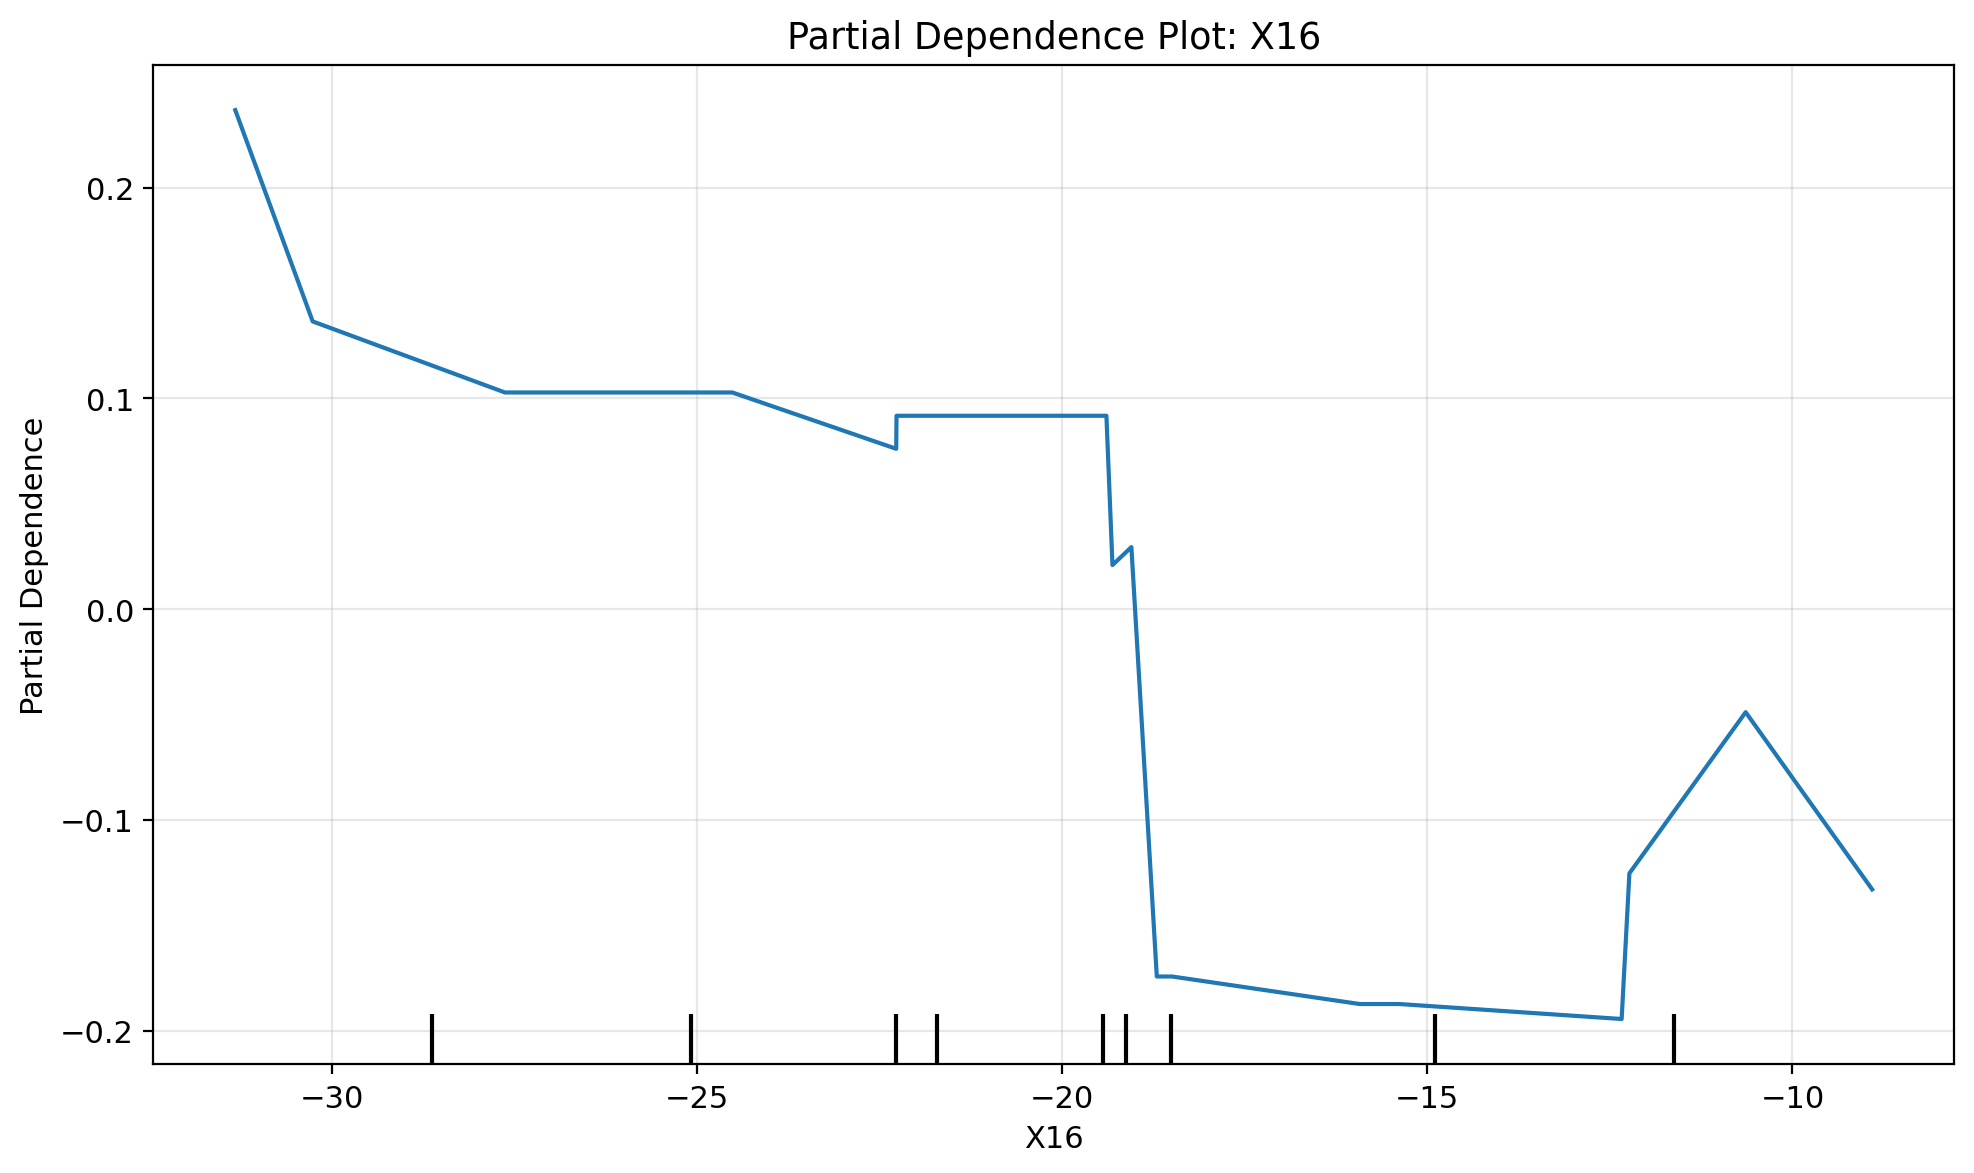

Generating partial dependence and ICE plots...


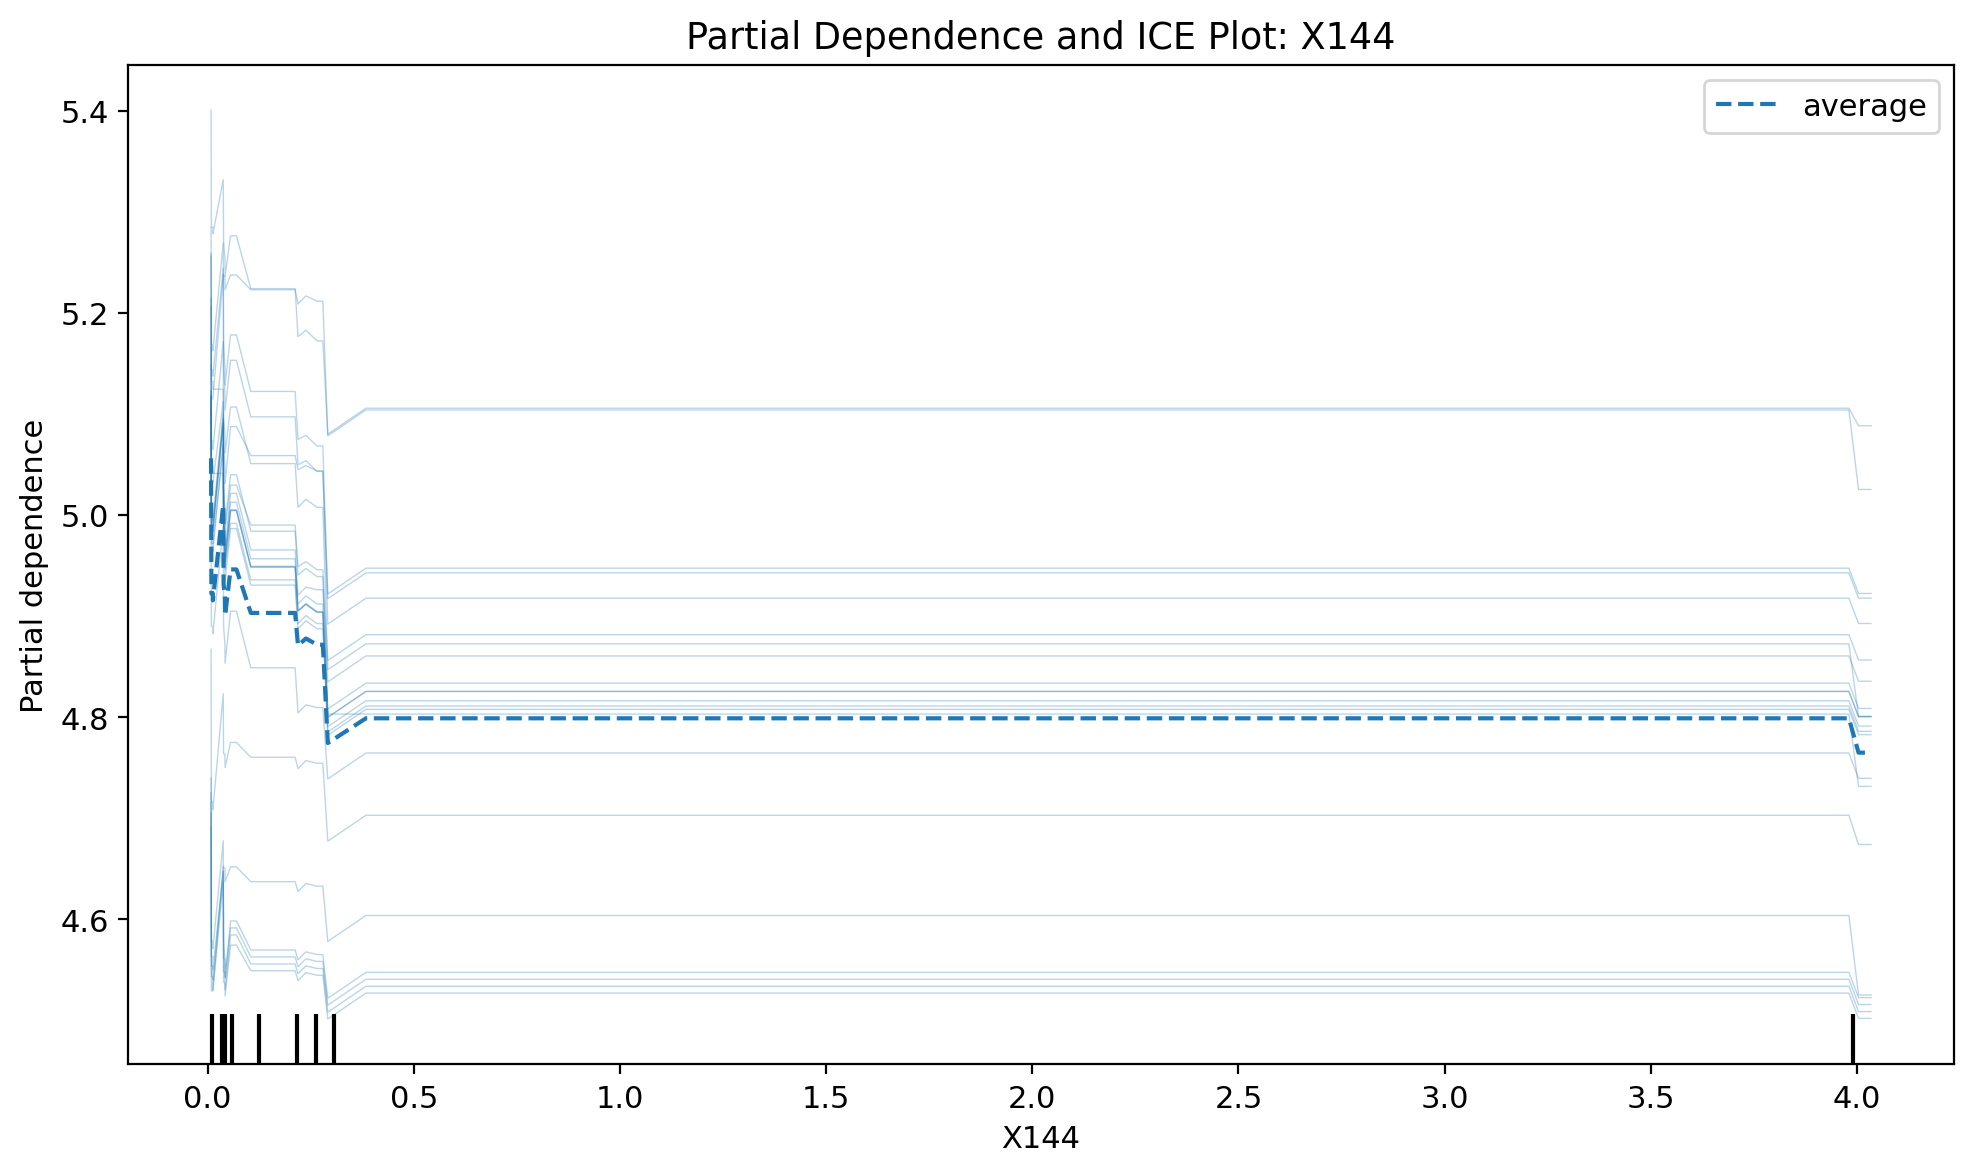

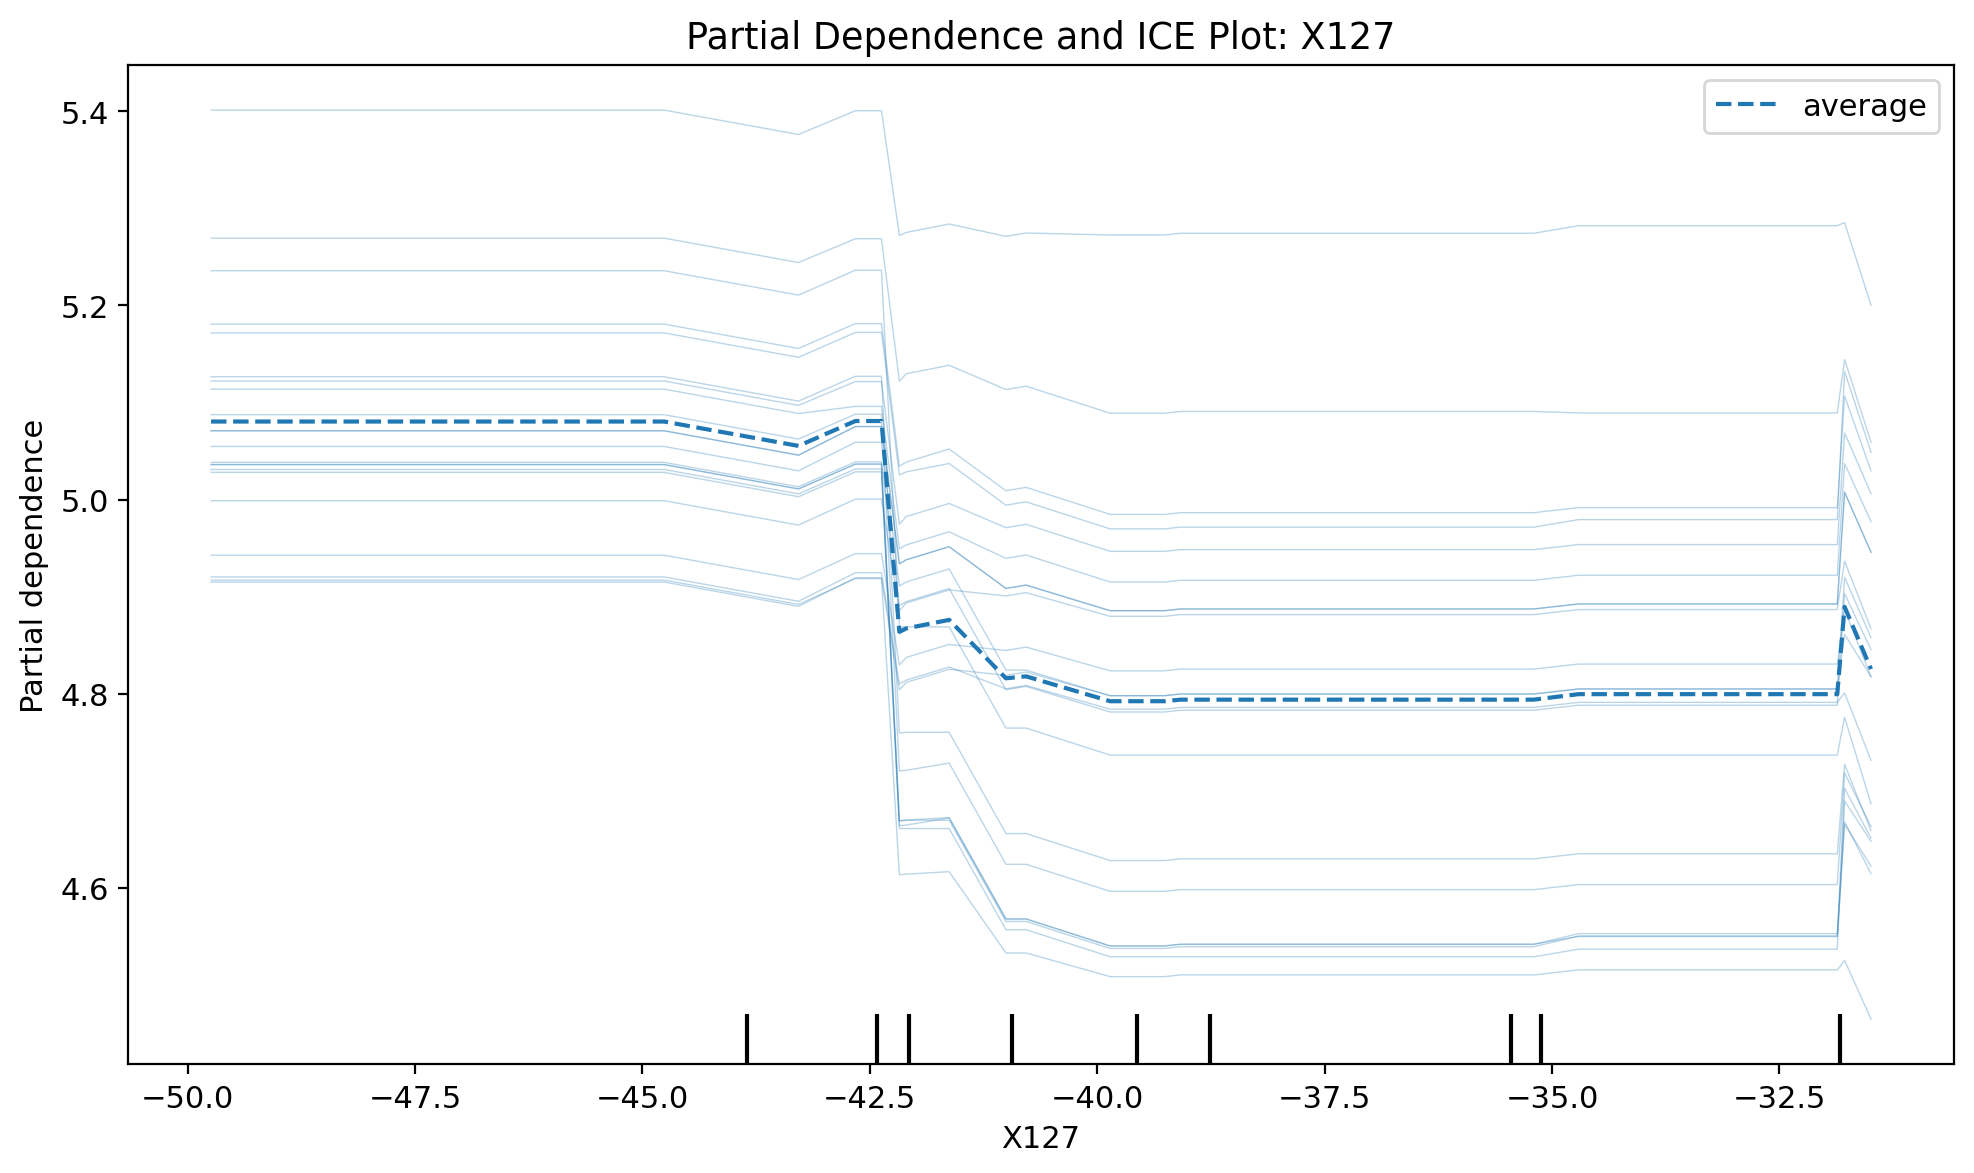

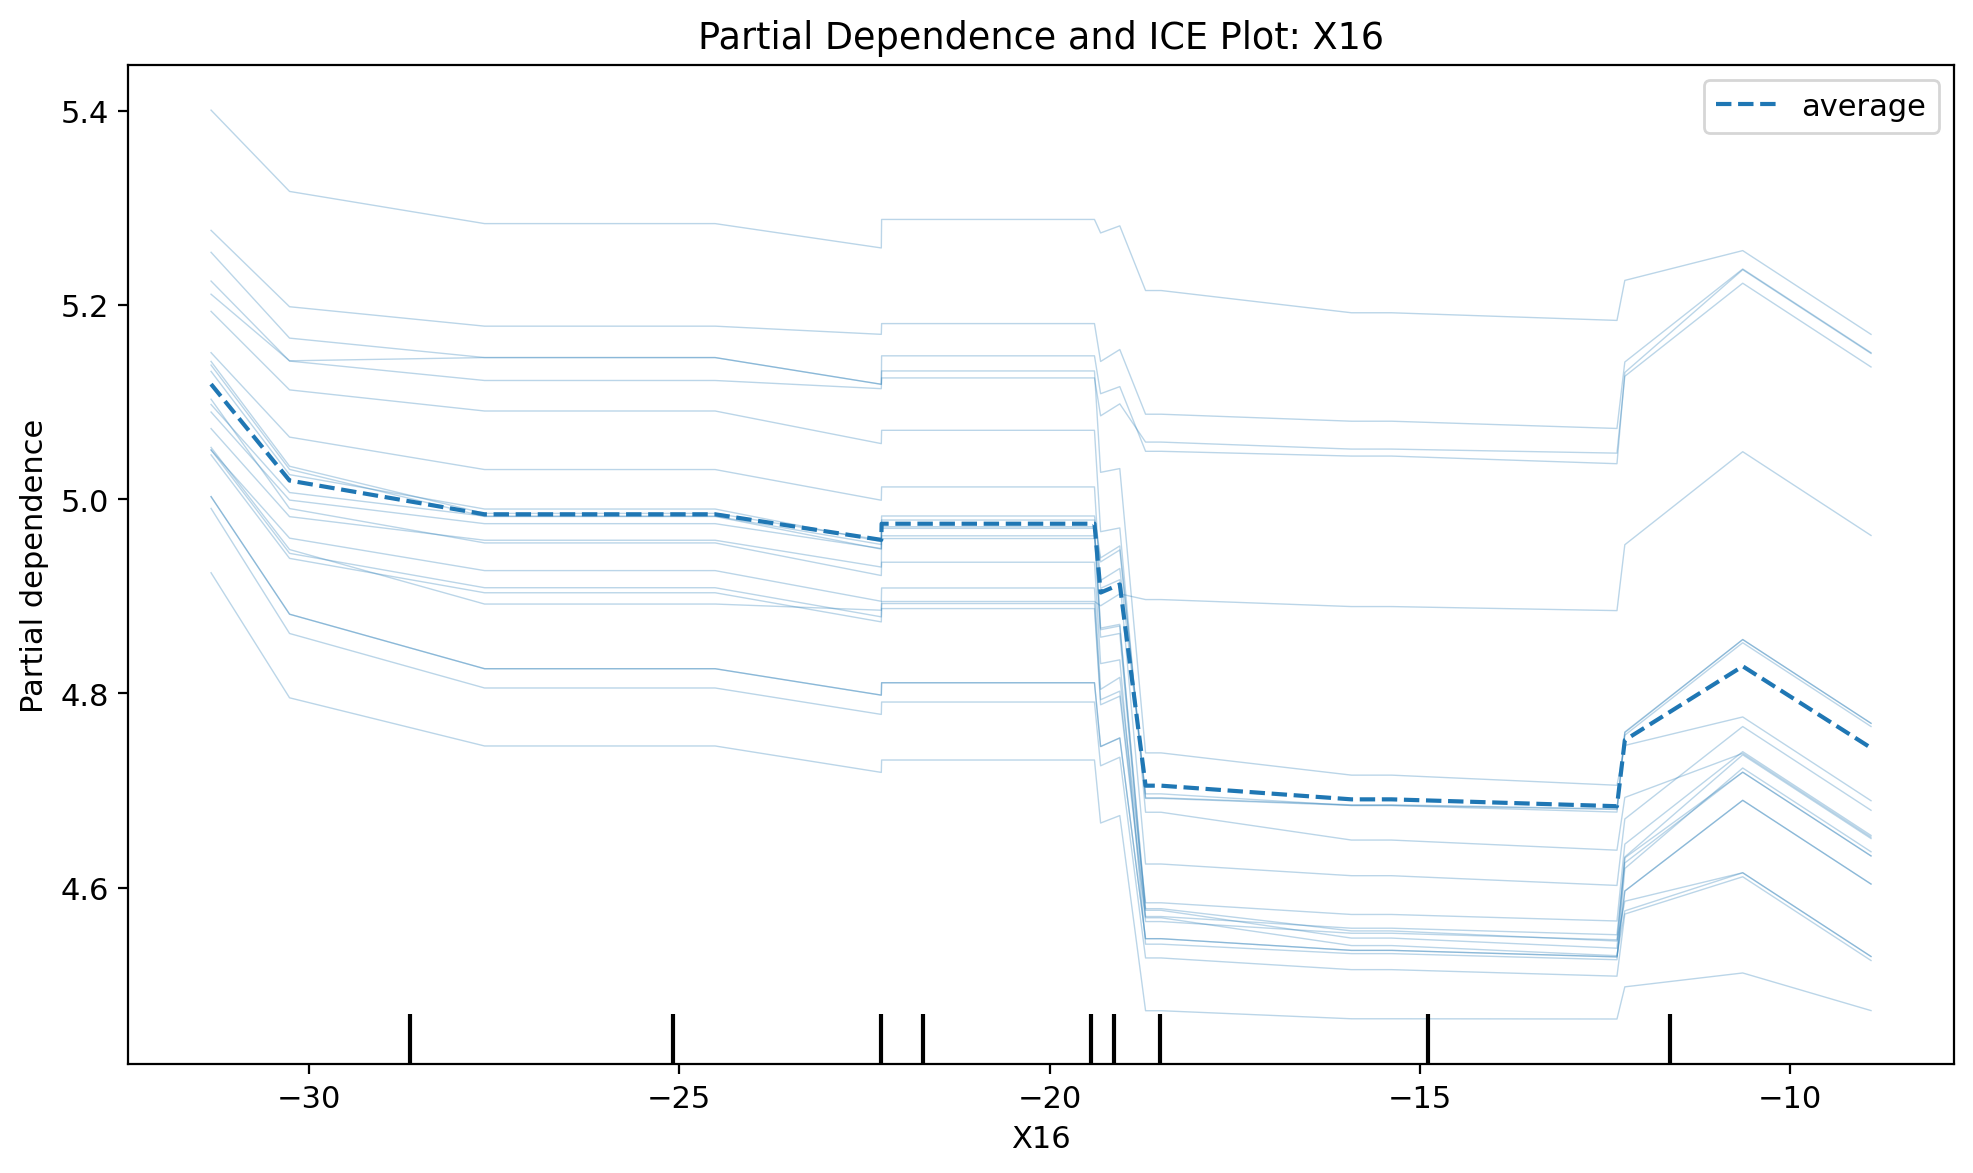

In [ ]:
# --- 7.6 SHAP Partial Dependence Plots ---
print("Generating SHAP partial dependence plots...") # Print status message
from sklearn.inspection import PartialDependenceDisplay # Import partial dependence plot tool from sklearn.inspection

top_pdp_features = top_3_features  # Select top 3 most important features for PDP analysis

# Generate PDP plots
for feature in top_pdp_features: # Iterate through these three features
    plt.figure(figsize=(10, 6)) # Create new figure window
    PartialDependenceDisplay.from_estimator( # Use from_estimator method to create PDP directly from model
        best_model, # Our trained model
        X_train, # PDP/ICE are typically calculated on training set to reflect model behavior
        features=[feature], # Specify feature to analyze
        kind='average', # 'average' means plot only the average partial dependence (PDP)
        grid_resolution=50, # Use 50 points across feature value range for calculation
        ax=plt.gca() # Plot on current Matplotlib axis
    )
    plt.title(f'Partial Dependence Plot: {feature}') # Set title
    plt.xlabel(feature) # Set X-axis label
    plt.ylabel('Partial Dependence') # Set Y-axis label
    plt.grid(True, alpha=0.3) # Add grid lines
    plt.tight_layout() # Auto-adjust layout

    # Simple filename sanitization - replace only the problematic characters we know about
    safe_feature_name = feature.replace('/', '_').replace('(', '_').replace(')', '_')
    plt.savefig(f'SHAP_PDP_{safe_feature_name}.png', dpi=300, bbox_inches='tight') # Save PDP plot
    plt.show() # Display PDP plot

# Create combined partial dependence and individual conditional expectation plots
print("Generating partial dependence and ICE plots...") # Print status message
for feature in top_pdp_features: # Iterate through the three features again
    fig, ax = plt.subplots(figsize=(10, 6)) # Create new figure and axis objects
    PartialDependenceDisplay.from_estimator( # Call plotting function again
        best_model, # Our trained model
        X_train, # Use training set again
        features=[feature], # Specify feature to analyze
        kind='both', # 'both' means plot both PDP (average line) and ICE (individual lines)
        grid_resolution=50, # Set same grid resolution
        ax=ax # Plot on specified axis
    )
    ax.set_title(f'Partial Dependence and ICE Plot: {feature}') # Set title
    ax.set_xlabel(feature) # Set X-axis label
    ax.set_ylabel('Partial Dependence / ICE') # Set Y-axis label
    ax.grid(True, alpha=0.3) # Add grid lines
    plt.tight_layout() # Auto-adjust layout

    # Simple filename sanitization
    safe_feature_name = feature.replace('/', '_').replace('(', '_').replace(')', '_')
    plt.savefig(f'SHAP_PDP_ICE_{safe_feature_name}.png', dpi=300, bbox_inches='tight') # Save PDP/ICE plot
    plt.show() # Display PDP/ICE plot